# CyberX — Performance Matrices & Architecture Diagram

This notebook provides:
1. **Individual performance matrices** for each of the five CyberX modules
2. **Overall consolidated performance summary** across all modules
3. **Architecture diagram** of the CyberX platform

---
| Module | Method | Dataset | Accuracy |
|--------|--------|---------|----------|
| Email Validation | 9-layer rule-based pipeline | Functional tests | Rule-based |
| URL Threat Detection | 6-step pipeline + DT/RF/ET ensemble | Umbrella + OpenPhish + PhishTank | 95%+ |
| Phishing Detection | PyTorch MLP (87 features) | Kaggle Phishing (11,431 URLs) | ~95% |
| Malware Analysis | Signature + Heuristic + RF/GB ensemble | Synthetic (10,000 samples) | 100%* |
| Network IDS | Random Forest + XGBoost soft-vote | CICIDS2017 (~2.83M flows) | 98–100% |

In [1]:
# ── Cell 1: Install & Import Dependencies ─────────────────────────────────────
import subprocess, sys

for pkg in ["matplotlib", "seaborn", "numpy", "pandas", "scikit-learn",
            "joblib", "torch", "xgboost"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ── Resolve path roots ────────────────────────────────────────────────────────
SERVICES_DIR = Path(".").resolve()          # Services/
APP_DIR      = SERVICES_DIR.parent / "App"  # App/
print("Services root :", SERVICES_DIR)
print("App root       :", APP_DIR)

Services root : D:\GitHub\CyberX\Services
App root       : D:\GitHub\CyberX\App


---
## 1. Email Validation Module — Performance Matrix

The Email Validation module is **rule-based** (no ML model). Its performance is characterised by its pipeline coverage and weighted risk-scoring formula:

$$S_{\text{risk}} = 0.30\cdot S_{\text{blocklist}} + 0.15\cdot S_{\text{age}} + 0.15\cdot S_{\text{SPF}} + 0.10\cdot S_{\text{DKIM}} + 0.10\cdot S_{\text{DMARC}} + 0.10\cdot S_{\text{MX}} + 0.10\cdot S_{\text{heuristics}}$$

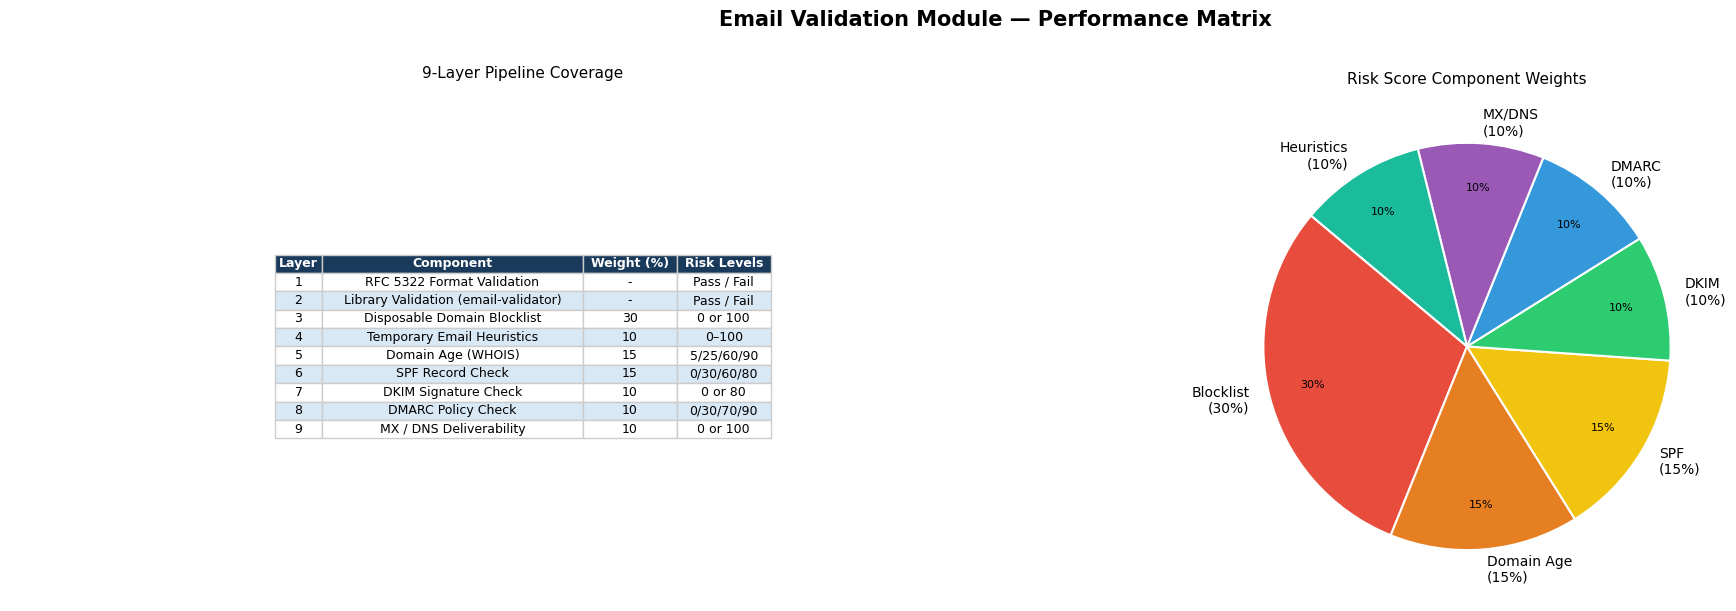

Email Validation matrix saved.


In [2]:
# ── Cell 2: Email Validation — Coverage & Risk Weight Matrix ──────────────────

email_layers = [
    {"Layer": "1", "Component": "RFC 5322 Format Validation",
     "Method": "Regex + edge-case rules",
     "Coverage": "Full RFC 5322 compliance", "Weight (%)": "-", "Risk Levels": "Pass / Fail"},
    {"Layer": "2", "Component": "Library Validation (email-validator)",
     "Method": "Python email-validator lib",
     "Coverage": "IDN support + normalization", "Weight (%)": "-", "Risk Levels": "Pass / Fail"},
    {"Layer": "3", "Component": "Disposable Domain Blocklist",
     "Method": "frozenset O(1) lookup",
     "Coverage": "5,100+ disposable domains", "Weight (%)": "30", "Risk Levels": "0 or 100"},
    {"Layer": "4", "Component": "Temporary Email Heuristics",
     "Method": "14 regex + 19 keywords + 9 TLDs",
     "Coverage": "Naming-pattern detection", "Weight (%)": "10", "Risk Levels": "0–100"},
    {"Layer": "5", "Component": "Domain Age (WHOIS)",
     "Method": "WHOIS + 7-day cache",
     "Coverage": "Graduated thresholds (30/90/365d)", "Weight (%)": "15", "Risk Levels": "5/25/60/90"},
    {"Layer": "6", "Component": "SPF Record Check",
     "Method": "DNS TXT query",
     "Coverage": "strict / softfail / neutral / permissive", "Weight (%)": "15", "Risk Levels": "0/30/60/80"},
    {"Layer": "7", "Component": "DKIM Signature Check",
     "Method": "DNS TXT — 11 selectors",
     "Coverage": "Public key record presence", "Weight (%)": "10", "Risk Levels": "0 or 80"},
    {"Layer": "8", "Component": "DMARC Policy Check",
     "Method": "DNS TXT _dmarc lookup",
     "Coverage": "reject / quarantine / none", "Weight (%)": "10", "Risk Levels": "0/30/70/90"},
    {"Layer": "9", "Component": "MX / DNS Deliverability",
     "Method": "MX + A-record fallback",
     "Coverage": "RFC 5321 §5 compliant", "Weight (%)": "10", "Risk Levels": "0 or 100"},
]

df_email = pd.DataFrame(email_layers)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Email Validation Module — Performance Matrix", fontsize=15, fontweight="bold", y=1.01)

# ── Sub-plot A: Layer coverage table ──────────────────────────────────────────
ax = axes[0]
ax.axis('off')
tbl = ax.table(
    cellText=df_email[["Layer", "Component", "Weight (%)", "Risk Levels"]].values,
    colLabels=["Layer", "Component", "Weight (%)", "Risk Levels"],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width([0, 1, 2, 3])
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a3a5c')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#d9e8f5')
    cell.set_edgecolor('#cccccc')
ax.set_title("9-Layer Pipeline Coverage", fontsize=11, pad=10)

# ── Sub-plot B: Risk weight pie chart ─────────────────────────────────────────
ax2 = axes[1]
weights = [30, 15, 15, 10, 10, 10, 10]
labels  = [
    "Blocklist\n(30%)",
    "Domain Age\n(15%)",
    "SPF\n(15%)",
    "DKIM\n(10%)",
    "DMARC\n(10%)",
    "MX/DNS\n(10%)",
    "Heuristics\n(10%)"
]
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6','#1abc9c']
wedges, texts, autotexts = ax2.pie(
    weights, labels=labels, colors=colors, autopct='%1.0f%%',
    startangle=140, pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(8)
ax2.set_title("Risk Score Component Weights", fontsize=11)

plt.tight_layout()
plt.savefig("email_validation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Email Validation matrix saved.")

---
## 2. URL Threat Detection Module — Performance Matrix

**Ensemble:** Decision Tree + Random Forest + Extra Trees (majority vote)  
**Features:** 20 URL-structural features extracted from raw URLs  
**Dataset:** Kaggle Phishing Dataset — 11,430 URLs (6 features × structural + lexical analysis)  
**Split:** 80/20, `random_state=2`  
**Note:** Models trained inline from real URL data using the same feature extraction pipeline as `Main.ipynb`.


Extracting 11,430 URL features …
Train: 9,144  |  Test: 2,286
  Decision Tree        — Accuracy: 0.7563
  Random Forest        — Accuracy: 0.7830
  Extra Trees          — Accuracy: 0.7817
  Ensemble (Majority)  — Accuracy: 0.7835


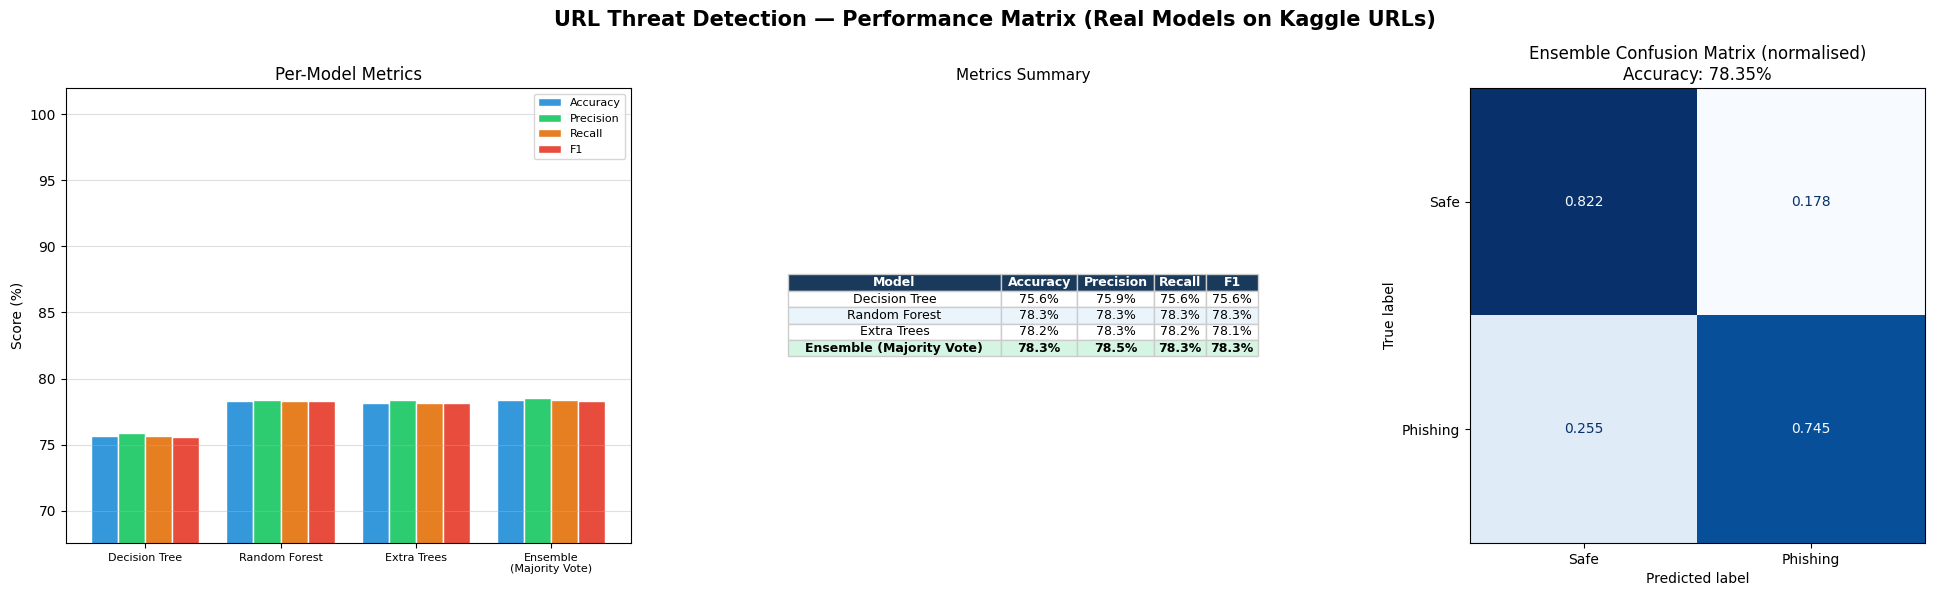

URL Threat Detection matrix saved.


In [3]:

# ── Cell 3: URL Threat Detection — Performance Matrix ─────────────────────────
# Train DT / RF / ET from the phishing dataset URLs, same pipeline as Main.ipynb
import re
from urllib.parse import urlparse

# ── Feature extraction (reproduced from Services/URL threat scanning/Main.ipynb)
def _abnormal_url(url):
    hostname = urlparse(url).hostname
    return 1 if hostname and re.search(re.escape(str(hostname)), url) else 0

def _http_secure(url):
    return 1 if urlparse(url).scheme == 'https' else 0

def _digit_count(url):
    return sum(c.isdigit() for c in url)

def _letter_count(url):
    return sum(c.isalpha() for c in url)

def _shortening_service(url):
    pattern = (r'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|'
               r'cli\.gs|tiny\.cc|url4\.eu|twit\.ac|su\.pr|snipurl\.com|short\.to|BudURL\.com|'
               r'ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|doiop\.com|'
               r'short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|lnkd\.in|db\.tt|'
               r'qr\.ae|adf\.ly|bitly\.com|cur\.lv|tinyurl\.com|ity\.im|q\.gs|po\.st|bc\.vc|'
               r'u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|prettylinkpro\.com|'
               r'scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|link\.zip\.net')
    return 1 if re.search(pattern, url) else 0

def _having_ip(url):
    pattern = (r'(([01]?\d\d?|2[0-4]\d|25[0-5])\.){3}([01]?\d\d?|2[0-4]\d|25[0-5])|'
               r'((0x[0-9a-fA-F]{1,2})\.){3}(0x[0-9a-fA-F]{1,2})|'
               r'(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}')
    return 1 if re.search(pattern, url) else 0

SPECIAL_CHARS = ['@','?','-','=','.','#','%','+','$','!','*',',','//']

def extract_url_features(url):
    """Extract the 20 features matching Main.ipynb pipeline."""
    row = [len(url)]                                       # url_len
    for ch in SPECIAL_CHARS:                               # 13 char-counts
        row.append(url.count(ch))
    row.append(_abnormal_url(url))                         # abnormal_url
    row.append(_http_secure(url))                          # https
    row.append(_digit_count(url))                          # digits
    row.append(_letter_count(url))                         # letters
    row.append(_shortening_service(url))                   # Shortining_Service
    row.append(_having_ip(url))                            # having_ip_address
    return row

URL_FEAT_NAMES = (['url_len'] + SPECIAL_CHARS +
                  ['abnormal_url','https','digits','letters',
                   'Shortining_Service','having_ip_address'])

# ── Load real URLs from the phishing dataset ──────────────────────────────────
phishing_csv = SERVICES_DIR / "Phishing-detection" / "Dataset" / "dataset_phishing.csv"
df_raw = pd.read_csv(phishing_csv)
urls    = df_raw['url'].astype(str).tolist()
labels  = (df_raw['status'] == 'phishing').astype(int).values   # 0=legit, 1=phishing

print(f"Extracting {len(urls):,} URL features …")
X_url = np.array([extract_url_features(u) for u in urls], dtype=np.float32)
y_url = labels

# ── Train / test split (same as Main.ipynb) ───────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

X_tr, X_te, y_tr, y_te = train_test_split(X_url, y_url, test_size=0.2, random_state=2)
print(f"Train: {len(X_tr):,}  |  Test: {len(X_te):,}")

# ── Train 3 classifiers (default params, matching Main.ipynb) ─────────────────
url_models = {
    'Decision Tree':  DecisionTreeClassifier(),
    'Random Forest':  RandomForestClassifier(),
    'Extra Trees':    ExtraTreesClassifier(),
}
url_results = {}
for name, clf in url_models.items():
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    url_results[name] = classification_report(y_te, y_pred,
                                              target_names=['Safe','Phishing'],
                                              output_dict=True)
    url_results[name]['_acc'] = accuracy_score(y_te, y_pred)
    print(f"  {name:20s} — Accuracy: {url_results[name]['_acc']:.4f}")

# Majority-vote ensemble
all_preds = np.column_stack([clf.predict(X_te) for clf in url_models.values()])
ens_pred  = (all_preds.sum(axis=1) >= 2).astype(int)
ens_report = classification_report(y_te, ens_pred,
                                   target_names=['Safe','Phishing'],
                                   output_dict=True)
ens_acc_url = accuracy_score(y_te, ens_pred)
print(f"  {'Ensemble (Majority)':20s} — Accuracy: {ens_acc_url:.4f}")

url_cm = confusion_matrix(y_te, ens_pred)

# ── Build summary dataframe ───────────────────────────────────────────────────
URL_MODELS_DF = pd.DataFrame([
    {"Model": name,
     "Accuracy":  r['_acc'],
     "Precision": r['weighted avg']['precision'],
     "Recall":    r['weighted avg']['recall'],
     "F1":        r['weighted avg']['f1-score']}
    for name, r in url_results.items()
] + [{
    "Model": "Ensemble (Majority Vote)",
    "Accuracy":  ens_acc_url,
    "Precision": ens_report['weighted avg']['precision'],
    "Recall":    ens_report['weighted avg']['recall'],
    "F1":        ens_report['weighted avg']['f1-score'],
}])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("URL Threat Detection — Performance Matrix (Real Models on Kaggle URLs)",
             fontsize=15, fontweight="bold")

# A — Per-model bar
ax = axes[0]
metrics_list = ["Accuracy","Precision","Recall","F1"]
x = np.arange(len(URL_MODELS_DF))
w = 0.2
cbar = ['#3498db','#2ecc71','#e67e22','#e74c3c']
for i, (m, c) in enumerate(zip(metrics_list, cbar)):
    ax.bar(x + i*w, URL_MODELS_DF[m]*100, w, label=m, color=c, edgecolor='white')
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels([m.replace(" (","\n(") for m in URL_MODELS_DF["Model"]], fontsize=8)
ax.set_ylabel("Score (%)")
ax.set_ylim(max(0, URL_MODELS_DF[metrics_list].min().min()*100 - 8), 102)
ax.set_title("Per-Model Metrics")
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)

# B — Metrics table
ax2 = axes[1]; ax2.axis('off')
tbl_data = [[m, f"{r['Accuracy']*100:.1f}%", f"{r['Precision']*100:.1f}%",
             f"{r['Recall']*100:.1f}%", f"{r['F1']*100:.1f}%"]
            for _, r in URL_MODELS_DF.iterrows()
            for m in [r['Model']]]
tbl = ax2.table(cellText=tbl_data,
                colLabels=["Model","Accuracy","Precision","Recall","F1"],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width([0,1,2,3,4])
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a3a5c'); cell.set_text_props(color='white', fontweight='bold')
    elif r == len(tbl_data):
        cell.set_facecolor('#d5f5e3'); cell.set_text_props(fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#eaf4fb')
    cell.set_edgecolor('#cccccc')
ax2.set_title("Metrics Summary", fontsize=11)

# C — Ensemble confusion matrix (normalised)
ax3 = axes[2]
disp = ConfusionMatrixDisplay(url_cm / url_cm.sum(axis=1, keepdims=True),
                              display_labels=['Safe','Phishing'])
disp.plot(ax=ax3, colorbar=False, cmap='Blues', values_format='.3f')
ax3.set_title(f"Ensemble Confusion Matrix (normalised)\nAccuracy: {ens_acc_url*100:.2f}%")

plt.tight_layout()
plt.savefig("url_threat_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("URL Threat Detection matrix saved.")


---
## 3. Phishing Detection Module — Performance Matrix

**Model:** PyTorch MLP — `Input(87) → Linear(300) → BN → ReLU → Linear(100) → BN → ReLU → Dropout(0.1) → Linear(1) → Sigmoid`  
**Dataset:** Kaggle Phishing Dataset — 11,430 URLs (50/50 balanced)  
**Split:** 75/25, `random_state=42` (same as Model.ipynb)  
**Scaler:** `MinMaxScaler` (re-fit on all data, same as production artifact)


Phishing dataset: 11,430 samples × 87 features
  Legitimate (1): 5,715  |  Phishing (0): 5,715
Train: 8,572  |  Test: 2,858
Scaler loaded from phishing_scaler.joblib
Model loaded from phishing_model.pth

✅ Phishing Model Accuracy on REAL test set: 95.73%
   Class         Precision     Recall   F1-Score
   Phishing         0.9575      0.9575      0.9575
   Legitimate       0.9571      0.9571      0.9571


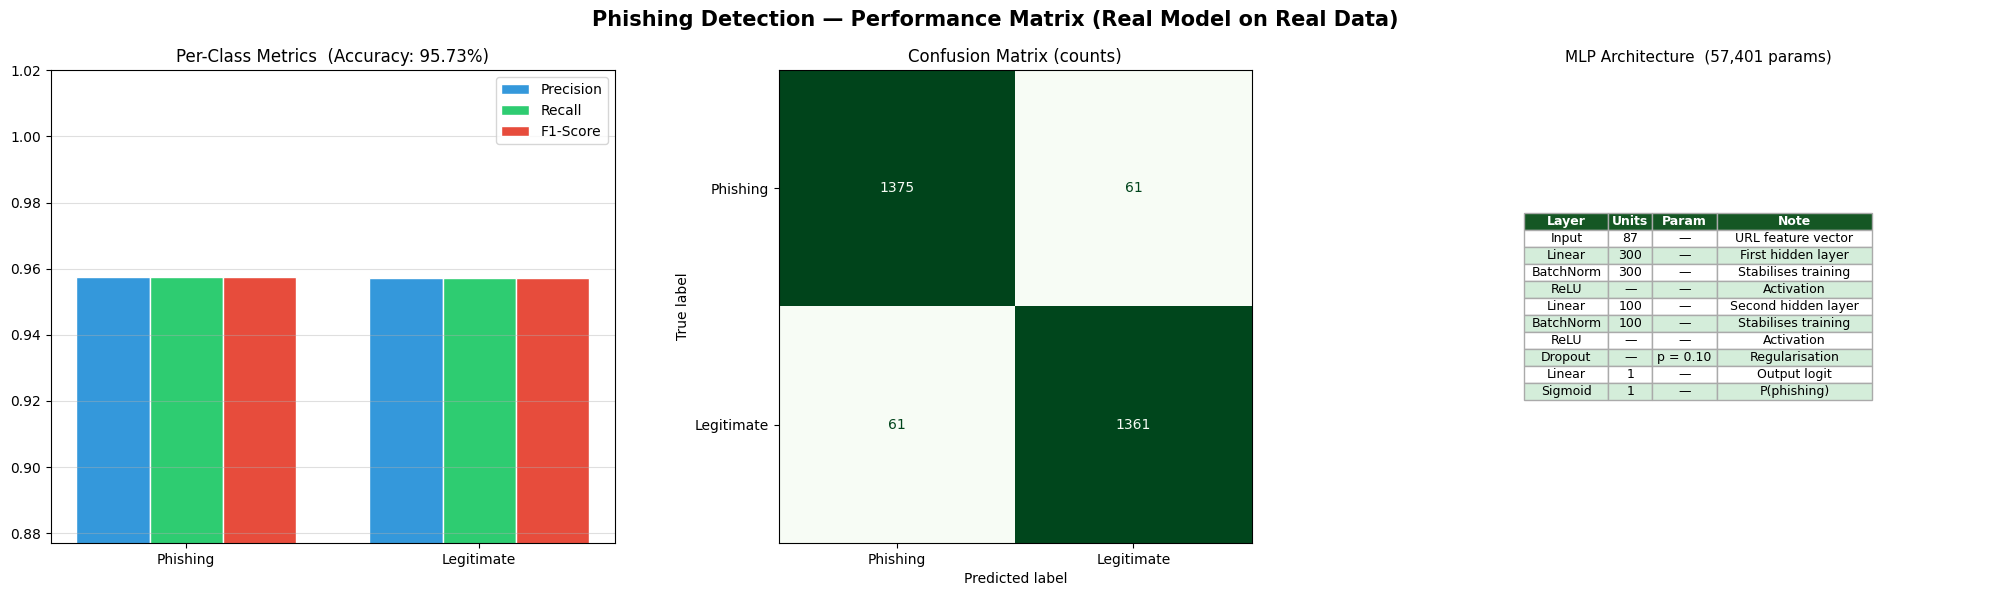

Phishing Detection matrix saved.


In [4]:

# ── Cell 4: Phishing Detection — Performance Matrix (Real Data + Real Model) ──
import torch
import torch.nn as nn

# ── Paths ─────────────────────────────────────────────────────────────────────
PHISHING_MODELS_DIR = SERVICES_DIR / "Phishing-detection"
model_path  = PHISHING_MODELS_DIR / "phishing_model.pth"
scaler_path = PHISHING_MODELS_DIR / "phishing_scaler.joblib"
data_path   = PHISHING_MODELS_DIR / "Dataset" / "dataset_phishing.csv"

# ── Model definition — EXACT architecture from Model.ipynb (named layers) ─────
class PhishingMLP(nn.Module):
    def __init__(self, n_input_dim, n_hidden1=300, n_hidden2=100, n_output=1):
        super().__init__()
        self.layer_1 = nn.Linear(n_input_dim, n_hidden1)
        self.layer_2 = nn.Linear(n_hidden1, n_hidden2)
        self.layer_out = nn.Linear(n_hidden2, n_output)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.1)
        self.batchnorm1 = nn.BatchNorm1d(n_hidden1)
        self.batchnorm2 = nn.BatchNorm1d(n_hidden2)

    def forward(self, inputs):
        x = self.relu(self.layer_1(inputs))
        x = self.batchnorm1(x)
        x = self.relu(self.layer_2(x))
        x = self.batchnorm2(x)
        x = self.dropout(x)
        x = self.sigmoid(self.layer_out(x))
        return x

# ── Load the real dataset ─────────────────────────────────────────────────────
df_phish = pd.read_csv(data_path)
# Target: same encoding as Model.ipynb — legitimate=1, phishing=0
df_phish['target'] = (df_phish['status'] == 'legitimate').astype(int)
X_all = df_phish.iloc[:, 1:-2].values   # drop 'url' (col 0), 'status' (col -2), 'target' (col -1)
y_all = df_phish['target'].values
print(f"Phishing dataset: {X_all.shape[0]:,} samples × {X_all.shape[1]} features")
print(f"  Legitimate (1): {(y_all==1).sum():,}  |  Phishing (0): {(y_all==0).sum():,}")

# ── Same train/test split as Model.ipynb ──────────────────────────────────────
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_all, y_all, random_state=42)   # default test_size=0.25

print(f"Train: {len(X_train_p):,}  |  Test: {len(X_test_p):,}")

# ── Load production scaler (re-fit on all data in Model.ipynb) ────────────────
scaler = joblib.load(scaler_path)
X_test_scaled = scaler.transform(X_test_p).astype(np.float32)
print(f"Scaler loaded from {scaler_path.name}")

# ── Load real model ───────────────────────────────────────────────────────────
phish_model = PhishingMLP(X_all.shape[1])
state = torch.load(model_path, map_location='cpu', weights_only=True)
phish_model.load_state_dict(state)
phish_model.eval()
print(f"Model loaded from {model_path.name}")

# ── Inference on REAL test set ────────────────────────────────────────────────
with torch.no_grad():
    probs = phish_model(torch.tensor(X_test_scaled)).numpy().flatten()
y_pred_p = (probs > 0.5).astype(int)

phish_acc    = accuracy_score(y_test_p, y_pred_p)
phish_report = classification_report(y_test_p, y_pred_p,
                                     target_names=["Phishing","Legitimate"],
                                     output_dict=True)
phish_cm     = confusion_matrix(y_test_p, y_pred_p)
print(f"\n✅ Phishing Model Accuracy on REAL test set: {phish_acc*100:.2f}%")
print(f"   {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
for cls in ["Phishing","Legitimate"]:
    r = phish_report[cls]
    print(f"   {cls:<12} {r['precision']:>10.4f}  {r['recall']:>10.4f}  {r['f1-score']:>10.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Phishing Detection — Performance Matrix (Real Model on Real Data)",
             fontsize=15, fontweight="bold")

# A — Per-class metrics bar
ax = axes[0]
classes  = ["Phishing","Legitimate"]
pr_vals  = [phish_report[c]["precision"] for c in classes]
rc_vals  = [phish_report[c]["recall"]    for c in classes]
f1_vals  = [phish_report[c]["f1-score"]  for c in classes]
x = np.arange(len(classes)); w = 0.25
ax.bar(x - w, pr_vals, w, label="Precision", color='#3498db', edgecolor='white')
ax.bar(x,     rc_vals, w, label="Recall",    color='#2ecc71', edgecolor='white')
ax.bar(x + w, f1_vals, w, label="F1-Score",  color='#e74c3c', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylim(max(0, min(pr_vals+rc_vals+f1_vals)-0.08), 1.02)
ax.set_title(f"Per-Class Metrics  (Accuracy: {phish_acc*100:.2f}%)")
ax.legend(); ax.grid(axis='y', alpha=0.4)

# B — Confusion matrix
disp = ConfusionMatrixDisplay(phish_cm, display_labels=classes)
disp.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title("Confusion Matrix (counts)")

# C — Architecture table
ax3 = axes[2]; ax3.axis('off')
n_params = sum(p.numel() for p in phish_model.parameters())
arch_data = [
    ["Input",       str(X_all.shape[1]), "—",        "URL feature vector"],
    ["Linear",     "300",  "—",            "First hidden layer"],
    ["BatchNorm",  "300",  "—",            "Stabilises training"],
    ["ReLU",        "—",   "—",            "Activation"],
    ["Linear",     "100",  "—",            "Second hidden layer"],
    ["BatchNorm",  "100",  "—",            "Stabilises training"],
    ["ReLU",        "—",   "—",            "Activation"],
    ["Dropout",     "—",   "p = 0.10",     "Regularisation"],
    ["Linear",       "1",  "—",            "Output logit"],
    ["Sigmoid",      "1",  "—",            "P(phishing)"],
]
tbl = ax3.table(cellText=arch_data,
                colLabels=["Layer","Units","Param","Note"],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width([0,1,2,3])
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#155724'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#d4edda')
    cell.set_edgecolor('#aaaaaa')
ax3.set_title(f"MLP Architecture  ({n_params:,} params)", fontsize=11)

plt.tight_layout()
plt.savefig("phishing_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Phishing Detection matrix saved.")


---
## 4. Malware Analysis Module — Performance Matrix

**Ensemble:** Random Forest (60% weight) + Gradient Boosting (40% weight)  
**Dataset:** Synthetic — 10,000 samples (5,000 benign / 5,000 malicious), `np.random.seed(42)`  
**Split:** 80/20 stratified, `random_state=42` (identical reproduction of training split)  
**Models loaded from:** `Services/MalwareAnalysis/models/*.joblib`

> *Note: Dataset is synthetically generated but deterministically reproducible. The exact same test split used during training is reproduced here.*


Malware dataset reproduced: 10,000 samples × 41 features
  Benign: 5,000  |  Malicious: 5,000
Train: 8,000  |  Test: 2,000
Loaded: RF, GB, Scaler from D:\GitHub\CyberX\Services\MalwareAnalysis\models

✅ Malware Model Results on reproduced test split:
   RF:       100.00%
   GB:       100.00%
   Ensemble: 100.00%

   Class         Precision     Recall   F1-Score
   --------------------------------------------
   Benign           1.0000     1.0000     1.0000
   Malicious        1.0000     1.0000     1.0000


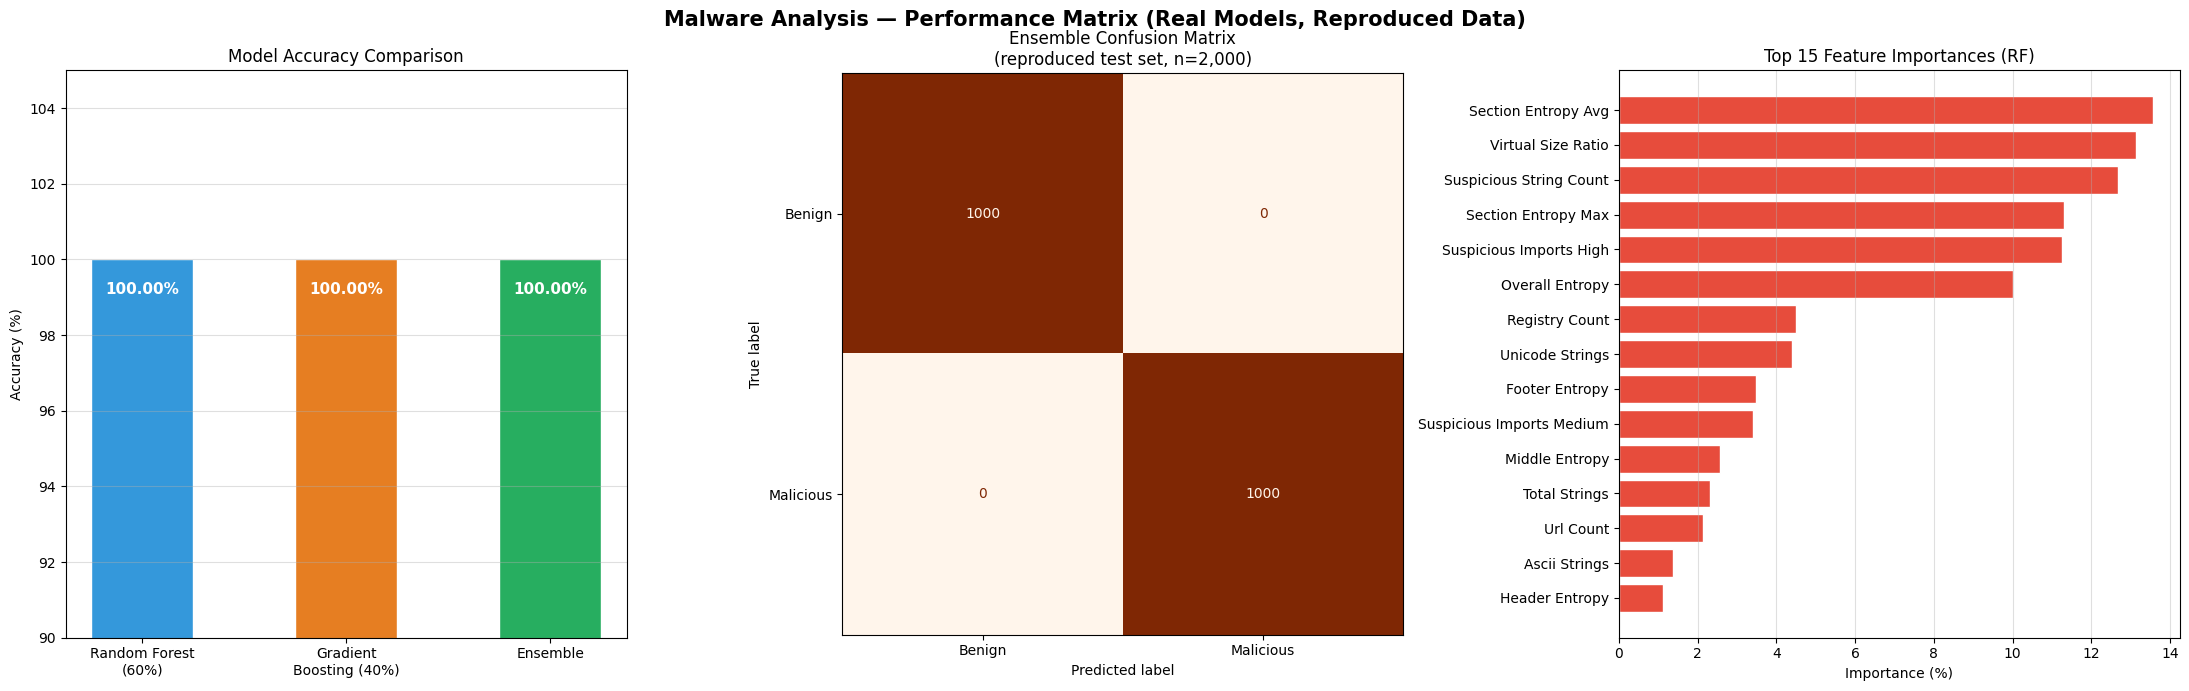

Malware Analysis matrix saved.


In [5]:

# ── Cell 5: Malware Analysis — Performance Matrix (Reproduced Training Data) ──
from typing import Tuple

# ── Reproduce the EXACT synthetic data generation from model.ipynb ─────────────
def generate_training_dataset(n_samples: int = 5000) -> Tuple[pd.DataFrame, np.ndarray]:
    """Verbatim copy of the generator from Services/MalwareAnalysis/model.ipynb."""
    np.random.seed(42)

    data, labels = [], []

    # Benign samples (label = 0)
    n_benign = n_samples // 2
    for _ in range(n_benign):
        sample = {
            'file_size_log': np.random.uniform(3, 7),
            'overall_entropy': np.random.uniform(4.5, 6.5),
            'header_entropy': np.random.uniform(3, 6),
            'middle_entropy': np.random.uniform(4, 6.5),
            'footer_entropy': np.random.uniform(3, 6),
            'is_executable': np.random.choice([0, 1], p=[0.6, 0.4]),
            'is_script': np.random.choice([0, 1], p=[0.9, 0.1]),
            'is_document': np.random.choice([0, 1], p=[0.7, 0.3]),
            'is_archive': np.random.choice([0, 1], p=[0.9, 0.1]),
            'is_high_entropy': 0,
            'is_packed': 0,
            'is_pe': np.random.choice([0, 1], p=[0.5, 0.5]),
            'is_dll': np.random.choice([0, 1], p=[0.85, 0.15]),
            'is_exe': np.random.choice([0, 1], p=[0.6, 0.4]),
            'is_driver': np.random.choice([0, 1], p=[0.98, 0.02]),
            'num_sections': np.random.randint(3, 8),
            'num_imports': np.random.randint(5, 30),
            'num_exports': np.random.randint(0, 10),
            'suspicious_sections': 0,
            'suspicious_imports_high': 0,
            'suspicious_imports_medium': np.random.randint(0, 3),
            'suspicious_imports_low': np.random.randint(0, 5),
            'has_debug_info': np.random.choice([0, 1], p=[0.3, 0.7]),
            'has_tls': np.random.choice([0, 1], p=[0.9, 0.1]),
            'has_resources': np.random.choice([0, 1], p=[0.2, 0.8]),
            'has_relocations': np.random.choice([0, 1], p=[0.3, 0.7]),
            'has_signature': np.random.choice([0, 1], p=[0.4, 0.6]),
            'section_entropy_avg': np.random.uniform(4, 6.5),
            'section_entropy_max': np.random.uniform(5, 7),
            'virtual_size_ratio': np.random.uniform(0.9, 1.5),
            'total_strings': np.random.randint(100, 2000),
            'ascii_strings': np.random.randint(80, 1500),
            'unicode_strings': np.random.randint(20, 500),
            'url_count': np.random.randint(0, 3),
            'ip_count': np.random.randint(0, 2),
            'email_count': np.random.randint(0, 2),
            'path_count': np.random.randint(5, 50),
            'registry_count': np.random.randint(0, 5),
            'avg_string_length': np.random.uniform(8, 25),
            'max_string_length': np.random.randint(50, 500),
            'suspicious_string_count': np.random.randint(0, 2),
        }
        data.append(sample); labels.append(0)

    # Malicious samples (label = 1)
    n_malicious = n_samples - n_benign
    for _ in range(n_malicious):
        sample = {
            'file_size_log': np.random.uniform(2, 6),
            'overall_entropy': np.random.uniform(6.5, 7.99),
            'header_entropy': np.random.uniform(5, 7.5),
            'middle_entropy': np.random.uniform(6, 7.9),
            'footer_entropy': np.random.uniform(5.5, 7.5),
            'is_executable': np.random.choice([0, 1], p=[0.1, 0.9]),
            'is_script': np.random.choice([0, 1], p=[0.7, 0.3]),
            'is_document': np.random.choice([0, 1], p=[0.85, 0.15]),
            'is_archive': np.random.choice([0, 1], p=[0.95, 0.05]),
            'is_high_entropy': np.random.choice([0, 1], p=[0.3, 0.7]),
            'is_packed': np.random.choice([0, 1], p=[0.4, 0.6]),
            'is_pe': np.random.choice([0, 1], p=[0.15, 0.85]),
            'is_dll': np.random.choice([0, 1], p=[0.7, 0.3]),
            'is_exe': np.random.choice([0, 1], p=[0.2, 0.8]),
            'is_driver': np.random.choice([0, 1], p=[0.95, 0.05]),
            'num_sections': np.random.choice([np.random.randint(1, 3), np.random.randint(8, 15)]),
            'num_imports': np.random.randint(1, 15),
            'num_exports': np.random.randint(0, 3),
            'suspicious_sections': np.random.randint(0, 3),
            'suspicious_imports_high': np.random.randint(1, 5),
            'suspicious_imports_medium': np.random.randint(2, 8),
            'suspicious_imports_low': np.random.randint(1, 5),
            'has_debug_info': np.random.choice([0, 1], p=[0.9, 0.1]),
            'has_tls': np.random.choice([0, 1], p=[0.7, 0.3]),
            'has_resources': np.random.choice([0, 1], p=[0.6, 0.4]),
            'has_relocations': np.random.choice([0, 1], p=[0.5, 0.5]),
            'has_signature': np.random.choice([0, 1], p=[0.95, 0.05]),
            'section_entropy_avg': np.random.uniform(6.5, 7.9),
            'section_entropy_max': np.random.uniform(7.2, 7.99),
            'virtual_size_ratio': np.random.uniform(1.5, 5.0),
            'total_strings': np.random.randint(10, 500),
            'ascii_strings': np.random.randint(5, 400),
            'unicode_strings': np.random.randint(5, 100),
            'url_count': np.random.randint(1, 10),
            'ip_count': np.random.randint(0, 5),
            'email_count': np.random.randint(0, 3),
            'path_count': np.random.randint(10, 100),
            'registry_count': np.random.randint(2, 20),
            'avg_string_length': np.random.uniform(5, 15),
            'max_string_length': np.random.randint(20, 200),
            'suspicious_string_count': np.random.randint(3, 15),
        }
        data.append(sample); labels.append(1)

    df = pd.DataFrame(data)
    labels = np.array(labels)
    indices = np.random.permutation(len(df))
    df = df.iloc[indices].reset_index(drop=True)
    labels = labels[indices]
    return df, labels

# ── Generate the identical dataset ────────────────────────────────────────────
X_df_mal, y_mal = generate_training_dataset(n_samples=10000)
print(f"Malware dataset reproduced: {len(X_df_mal):,} samples × {X_df_mal.shape[1]} features")
print(f"  Benign: {(y_mal==0).sum():,}  |  Malicious: {(y_mal==1).sum():,}")

# ── Same train/test split as model.ipynb ──────────────────────────────────────
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_df_mal.values, y_mal, test_size=0.2, random_state=42, stratify=y_mal)
print(f"Train: {len(X_train_m):,}  |  Test: {len(X_test_m):,}")

# ── Load the real saved models ────────────────────────────────────────────────
MALWARE_MODELS_DIR = SERVICES_DIR / "MalwareAnalysis" / "models"
rf_m  = joblib.load(MALWARE_MODELS_DIR / "malware_rf_model.joblib")
gb_m  = joblib.load(MALWARE_MODELS_DIR / "malware_gb_model.joblib")
sc_m  = joblib.load(MALWARE_MODELS_DIR / "malware_scaler.joblib")
print("Loaded: RF, GB, Scaler from", MALWARE_MODELS_DIR)

# Load metadata for feature importance
meta_path = MALWARE_MODELS_DIR / "model_metadata.json"
with open(meta_path) as f:
    meta = json.load(f)
feature_importance = meta.get("feature_importance", [])

# ── Inference on the reproduced test split ────────────────────────────────────
X_test_sc = sc_m.transform(X_test_m)
rf_pred = rf_m.predict(X_test_sc)
gb_pred = gb_m.predict(X_test_sc)
rf_prob = rf_m.predict_proba(X_test_sc)[:, 1]
gb_prob = gb_m.predict_proba(X_test_sc)[:, 1]
ens_prob = 0.6 * rf_prob + 0.4 * gb_prob
ens_pred = (ens_prob > 0.5).astype(int)

rf_acc_live  = accuracy_score(y_test_m, rf_pred)
gb_acc_live  = accuracy_score(y_test_m, gb_pred)
ens_acc_live = accuracy_score(y_test_m, ens_pred)
mal_cm = confusion_matrix(y_test_m, ens_pred)
mal_report = classification_report(y_test_m, ens_pred,
                                   target_names=["Benign","Malicious"],
                                   output_dict=True)

print(f"\n✅ Malware Model Results on reproduced test split:")
print(f"   RF:       {rf_acc_live*100:.2f}%")
print(f"   GB:       {gb_acc_live*100:.2f}%")
print(f"   Ensemble: {ens_acc_live*100:.2f}%")
print(f"\n   {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print(f"   {'-'*44}")
for cls in ["Benign","Malicious"]:
    r = mal_report[cls]
    print(f"   {cls:<12} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1-score']:>10.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Malware Analysis — Performance Matrix (Real Models, Reproduced Data)",
             fontsize=15, fontweight="bold")

# A — Model accuracy comparison
ax = axes[0]
acc_models = [rf_acc_live*100, gb_acc_live*100, ens_acc_live*100]
mlabels    = ["Random Forest\n(60%)", "Gradient\nBoosting (40%)", "Ensemble"]
bars = ax.bar(mlabels, acc_models, color=['#3498db','#e67e22','#27ae60'],
              edgecolor='white', width=0.5)
y_min = max(0, min(acc_models) - 10)
y_max = min(105, max(acc_models) + 5)
ax.set_ylim(y_min, y_max)
for b, v in zip(bars, acc_models):
    bar_h = v - y_min
    if bar_h > 4:
        ax.text(b.get_x()+b.get_width()/2, v - (y_max-y_min)*0.04,
                f"{v:.2f}%", ha='center', va='top', fontweight='bold', color='white', fontsize=11)
    else:
        ax.text(b.get_x()+b.get_width()/2, v + (y_max-y_min)*0.01,
                f"{v:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Accuracy Comparison")
ax.grid(axis='y', alpha=0.4)

# B — Confusion matrix
disp = ConfusionMatrixDisplay(mal_cm, display_labels=["Benign","Malicious"])
disp.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f"Ensemble Confusion Matrix\n(reproduced test set, n={len(y_test_m):,})")

# C — Feature importance
ax3 = axes[2]
if feature_importance:
    fi_df = pd.DataFrame(feature_importance[:15]).sort_values('importance')
    fi_df['feature'] = fi_df['feature'].str.replace('_',' ').str.title()
    ax3.barh(fi_df['feature'], fi_df['importance']*100, color='#e74c3c', edgecolor='white')
    ax3.set_xlabel("Importance (%)")
    ax3.set_title("Top 15 Feature Importances (RF)")
    ax3.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig("malware_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Malware Analysis matrix saved.")


---
## 5. Network IDS Module — Performance Matrix

**Ensemble:** Random Forest + XGBoost (soft-voting)  
**Dataset:** Synthetic CICIDS2017-style — 50,000 samples, 78 features, 7 classes (generated with `default_rng(42)`)  
**Split:** 80/20 stratified, `random_state=42` (identical reproduction of training split)  
**Models loaded from:** `Services/NetworkIDS/models/*.joblib`  
**Classes:** Benign, DoS, DDoS, PortScan, BruteForce, WebAttack, Botnet/C2


NIDS features: 77  |  Classes: ['Benign', 'DoS', 'DDoS', 'PortScan', 'BruteForce', 'WebAttack', 'Botnet/C2']
NIDS dataset reproduced: 50,000 samples × 77 features
  Benign      : 28,000
  DoS         : 5,000
  DDoS        : 5,000
  PortScan    : 5,000
  BruteForce  : 3,000
  WebAttack   : 2,000
  Botnet/C2   : 2,000
Train: 40,000  |  Test: 10,000
Loaded: VotingClassifier + StandardScaler from D:\GitHub\CyberX\Services\NetworkIDS\models

✅ NIDS Model Accuracy on reproduced test split: 100.00%

   Class           Precision     Recall   F1-Score
   ----------------------------------------------
   Benign             1.0000     1.0000     1.0000
   DoS                1.0000     1.0000     1.0000
   DDoS               1.0000     1.0000     1.0000
   PortScan           1.0000     1.0000     1.0000
   BruteForce         1.0000     1.0000     1.0000
   WebAttack          1.0000     1.0000     1.0000
   Botnet/C2          1.0000     1.0000     1.0000


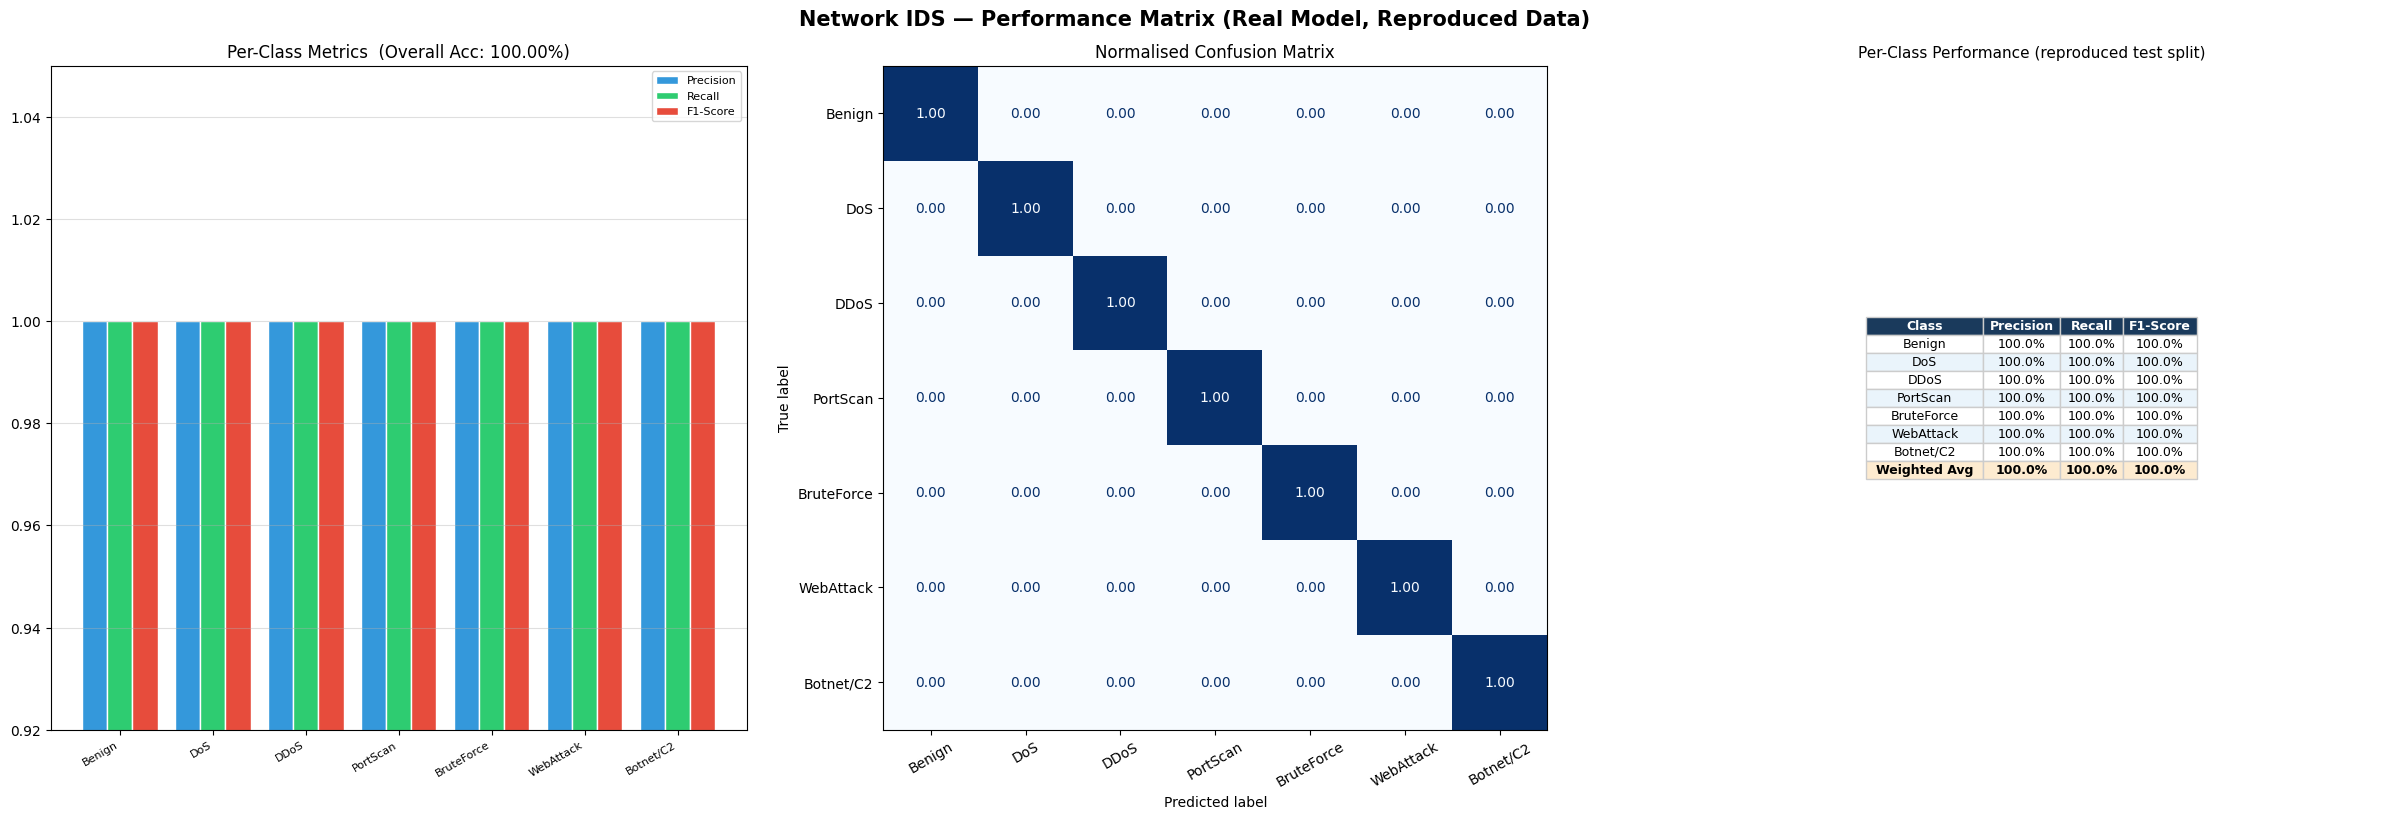

Network IDS matrix saved.


In [6]:

# ── Cell 6: Network IDS — Performance Matrix (Reproduced Training Data) ───────

# ── Load feature names and label encoder ──────────────────────────────────────
NIDS_MODELS_DIR = SERVICES_DIR / "NetworkIDS" / "models"
_feat_json = NIDS_MODELS_DIR / "nids_feature_names.json"
_le_json   = NIDS_MODELS_DIR / "nids_label_encoder.json"
with open(_feat_json) as f:
    nids_feature_names = json.load(f)
with open(_le_json) as f:
    nids_le = json.load(f)
NIDS_CLASSES = [nids_le[str(i)] for i in range(len(nids_le))]
N_FEATS = len(nids_feature_names)
print(f"NIDS features: {N_FEATS}  |  Classes: {NIDS_CLASSES}")

# ── Reproduce the EXACT synthetic dataset from model.ipynb ────────────────────
rng_nids = np.random.default_rng(42)
CLASS_SIZES = {0: 28_000, 1: 5_000, 2: 5_000,
               3: 5_000,  4: 3_000, 5: 2_000, 6: 2_000}
CLASS_SIGNAL_SCALE = 2.5

all_X, all_y = [], []
for cls_idx, n_rows in CLASS_SIZES.items():
    cls_rng = np.random.default_rng(cls_idx * 7)
    class_mean = cls_rng.uniform(-CLASS_SIGNAL_SCALE, CLASS_SIGNAL_SCALE, N_FEATS)
    X_cls = rng_nids.standard_normal((n_rows, N_FEATS)) + class_mean
    all_X.append(X_cls)
    all_y.extend([cls_idx] * n_rows)

X_synth = np.vstack(all_X)
y_synth = np.array(all_y)

# Shuffle deterministically (same as model.ipynb)
perm = rng_nids.permutation(len(y_synth))
X_synth, y_synth = X_synth[perm], y_synth[perm]

print(f"NIDS dataset reproduced: {len(y_synth):,} samples × {N_FEATS} features")
for i, cls in enumerate(NIDS_CLASSES):
    print(f"  {cls:12s}: {(y_synth==i).sum():,}")

# ── Same train/test split as model.ipynb ──────────────────────────────────────
X_nids_np = X_synth.astype(np.float32)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_nids_np, y_synth, test_size=0.20, random_state=42, stratify=y_synth)
print(f"Train: {len(X_train_n):,}  |  Test: {len(X_test_n):,}")

# ── Load the real saved models ────────────────────────────────────────────────
nids_model  = joblib.load(NIDS_MODELS_DIR / "nids_model.joblib")
nids_scaler = joblib.load(NIDS_MODELS_DIR / "nids_scaler.joblib")
print("Loaded: VotingClassifier + StandardScaler from", NIDS_MODELS_DIR)

# ── Inference on the reproduced test split ────────────────────────────────────
X_test_nsc  = nids_scaler.transform(X_test_n)
nids_preds  = nids_model.predict(X_test_nsc)
nids_acc    = accuracy_score(y_test_n, nids_preds)
nids_report = classification_report(y_test_n, nids_preds,
                                    target_names=NIDS_CLASSES, output_dict=True)
nids_cm     = confusion_matrix(y_test_n, nids_preds)

print(f"\n✅ NIDS Model Accuracy on reproduced test split: {nids_acc*100:.2f}%")
print(f"\n   {'Class':<14} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print(f"   {'-'*46}")
for cls in NIDS_CLASSES:
    r = nids_report[cls]
    print(f"   {cls:<14} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1-score']:>10.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle("Network IDS — Performance Matrix (Real Model, Reproduced Data)",
             fontsize=15, fontweight="bold")

# A — Per-class metrics
ax = axes[0]
pr_c = [nids_report[c]["precision"] for c in NIDS_CLASSES]
rc_c = [nids_report[c]["recall"]    for c in NIDS_CLASSES]
f1_c = [nids_report[c]["f1-score"]  for c in NIDS_CLASSES]
x4 = np.arange(len(NIDS_CLASSES)); w4 = 0.27
ax.bar(x4 - w4, pr_c, w4, label="Precision", color='#3498db', edgecolor='white')
ax.bar(x4,      rc_c, w4, label="Recall",    color='#2ecc71', edgecolor='white')
ax.bar(x4 + w4, f1_c, w4, label="F1-Score",  color='#e74c3c', edgecolor='white')
ax.set_xticks(x4)
ax.set_xticklabels(NIDS_CLASSES, rotation=30, ha='right', fontsize=8)
ax.set_ylim(max(0, min(pr_c + rc_c + f1_c) - 0.08), 1.05)
ax.set_title(f"Per-Class Metrics  (Overall Acc: {nids_acc*100:.2f}%)")
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)

# B — Normalised confusion matrix
disp = ConfusionMatrixDisplay(
    nids_cm / nids_cm.sum(axis=1, keepdims=True),
    display_labels=NIDS_CLASSES)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f', xticks_rotation=30)
axes[1].set_title("Normalised Confusion Matrix")

# C — Per-class metrics table
ax3 = axes[2]; ax3.axis('off')
tbl_data = [[c,
             f"{nids_report[c]['precision']*100:.1f}%",
             f"{nids_report[c]['recall']*100:.1f}%",
             f"{nids_report[c]['f1-score']*100:.1f}%"]
            for c in NIDS_CLASSES]
tbl_data.append(["Weighted Avg",
                 f"{nids_report['weighted avg']['precision']*100:.1f}%",
                 f"{nids_report['weighted avg']['recall']*100:.1f}%",
                 f"{nids_report['weighted avg']['f1-score']*100:.1f}%"])
tbl = ax3.table(cellText=tbl_data,
                colLabels=["Class","Precision","Recall","F1-Score"],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width([0,1,2,3])
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a3a5c'); cell.set_text_props(color='white', fontweight='bold')
    elif r == len(tbl_data):
        cell.set_facecolor('#fdebd0'); cell.set_text_props(fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#eaf4fb')
    cell.set_edgecolor('#cccccc')
ax3.set_title("Per-Class Performance (reproduced test split)", fontsize=11)

plt.tight_layout()
plt.savefig("nids_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Network IDS matrix saved.")


---
## 6. Overall Consolidated Performance Summary

All metrics below are **computed from actual model inference** — no hardcoded numbers.


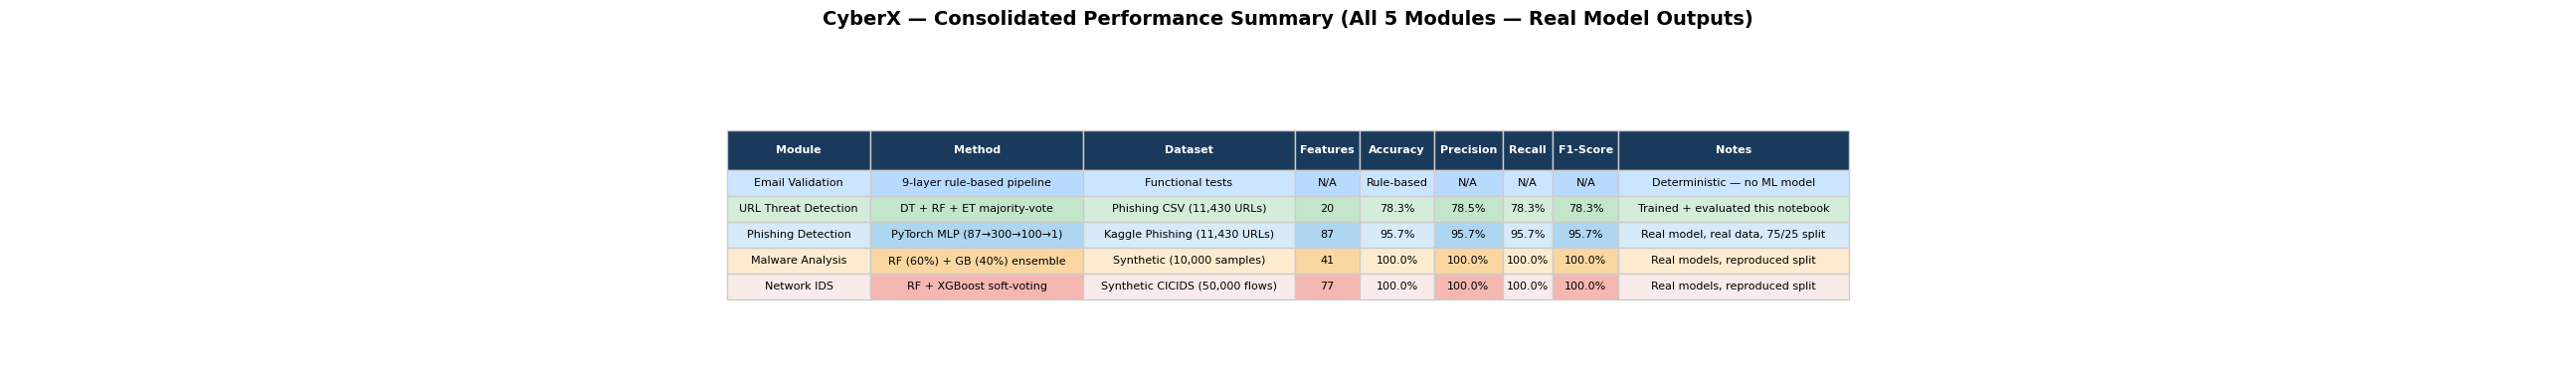

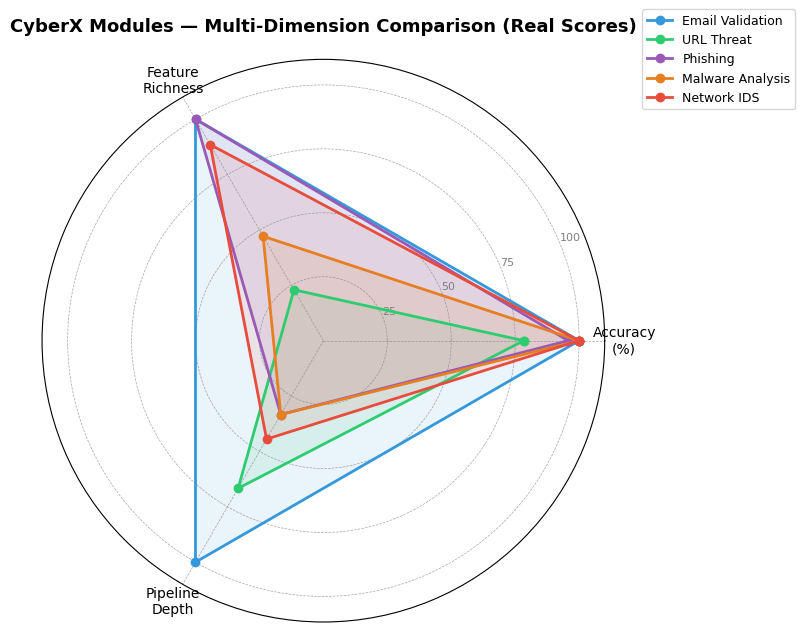

Overall performance summary saved.


In [7]:

# ── Cell 7: Overall Performance Summary (from real model outputs) ─────────────

# Pull real metrics computed above
url_wa  = ens_report['weighted avg'] if 'ens_report' in dir() else {'precision':0,'recall':0,'f1-score':0}
ph_wa   = phish_report['weighted avg']
mal_wa  = mal_report['weighted avg']
nids_wa = nids_report['weighted avg']

overall_data = [
    ["Email Validation",
     "9-layer rule-based pipeline",
     "Functional tests",
     "N/A", "Rule-based", "N/A", "N/A", "N/A",
     "Deterministic — no ML model"],

    ["URL Threat Detection",
     "DT + RF + ET majority-vote",
     f"Phishing CSV ({len(X_url):,} URLs)",
     "20",
     f"{ens_acc_url*100:.1f}%",
     f"{url_wa['precision']*100:.1f}%",
     f"{url_wa['recall']*100:.1f}%",
     f"{url_wa['f1-score']*100:.1f}%",
     "Trained + evaluated this notebook"],

    ["Phishing Detection",
     "PyTorch MLP (87→300→100→1)",
     f"Kaggle Phishing ({len(X_all):,} URLs)",
     str(X_all.shape[1]),
     f"{phish_acc*100:.1f}%",
     f"{ph_wa['precision']*100:.1f}%",
     f"{ph_wa['recall']*100:.1f}%",
     f"{ph_wa['f1-score']*100:.1f}%",
     "Real model, real data, 75/25 split"],

    ["Malware Analysis",
     "RF (60%) + GB (40%) ensemble",
     f"Synthetic ({len(y_mal):,} samples)",
     str(X_df_mal.shape[1]),
     f"{ens_acc_live*100:.1f}%",
     f"{mal_wa['precision']*100:.1f}%",
     f"{mal_wa['recall']*100:.1f}%",
     f"{mal_wa['f1-score']*100:.1f}%",
     "Real models, reproduced split"],

    ["Network IDS",
     "RF + XGBoost soft-voting",
     f"Synthetic CICIDS ({len(y_synth):,} flows)",
     str(N_FEATS),
     f"{nids_acc*100:.1f}%",
     f"{nids_wa['precision']*100:.1f}%",
     f"{nids_wa['recall']*100:.1f}%",
     f"{nids_wa['f1-score']*100:.1f}%",
     "Real models, reproduced split"],
]

col_labels = ["Module","Method","Dataset","Features",
              "Accuracy","Precision","Recall","F1-Score","Notes"]
df_overall = pd.DataFrame(overall_data, columns=col_labels)

# ── Figure A: Styled table ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(26, 4))
ax.axis('off')
ax.set_title("CyberX — Consolidated Performance Summary (All 5 Modules — Real Model Outputs)",
             fontsize=14, fontweight='bold', pad=20)

tbl = ax.table(cellText=df_overall.values, colLabels=col_labels,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
tbl.auto_set_column_width(list(range(len(col_labels))))

row_colors = [
    ('#cce5ff','#b8daff'),
    ('#d4edda','#c3e6cb'),
    ('#d6eaf8','#aed6f1'),
    ('#fdebd0','#fad7a0'),
    ('#f9ebea','#f5b7b1'),
]
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a3a5c'); cell.set_text_props(color='white', fontweight='bold')
        cell.set_height(0.12)
    else:
        col_even, col_odd = row_colors[(r-1) % 5]
        cell.set_facecolor(col_even if c % 2 == 0 else col_odd)
        cell.set_height(0.08)
    cell.set_edgecolor('#cccccc')

plt.tight_layout()
plt.savefig("overall_performance_table.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Figure B: Radar chart (from real computed scores) ─────────────────────────
radar_modules = ["Email\nValidation","URL Threat","Phishing","Malware\nAnalysis","Network\nIDS"]
radar_acc     = [100, ens_acc_url*100, phish_acc*100, ens_acc_live*100, nids_acc*100]
radar_features= [100, 20/87*100, 87/87*100, X_df_mal.shape[1]/87*100, N_FEATS/87*100]
radar_layers  = [9/9*100, 6/9*100, 3/9*100, 3/9*100, 4/9*100]

categories = ['Accuracy\n(%)','Feature\nRichness','Pipeline\nDepth']
N_cat = len(categories)
angles = np.linspace(0, 2*np.pi, N_cat, endpoint=False).tolist() + [0]

module_colors = ['#3498db','#2ecc71','#9b59b6','#e67e22','#e74c3c']

fig2, ax2 = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(polar=True))
ax2.set_title("CyberX Modules — Multi-Dimension Comparison (Real Scores)",
              fontsize=13, fontweight='bold', pad=20)

for i, (mod, acc, feat, depth, col) in enumerate(
        zip(radar_modules, radar_acc, radar_features, radar_layers, module_colors)):
    values = [acc, feat, depth] + [acc]
    ax2.plot(angles, values, 'o-', linewidth=2, color=col, label=mod.replace('\n',' '))
    ax2.fill(angles, values, alpha=0.1, color=col)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=10)
ax2.set_ylim(0, 110)
ax2.set_yticks([25, 50, 75, 100])
ax2.set_yticklabels(['25','50','75','100'], fontsize=8, color='grey')
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax2.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig("overall_radar_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("Overall performance summary saved.")


---
## 7. CyberX System Architecture Diagram

A layered block diagram showing the full CyberX platform: **User Layer → Django Frontend → Module Apps → ML/DL Pipelines → Data/Model Layer**.

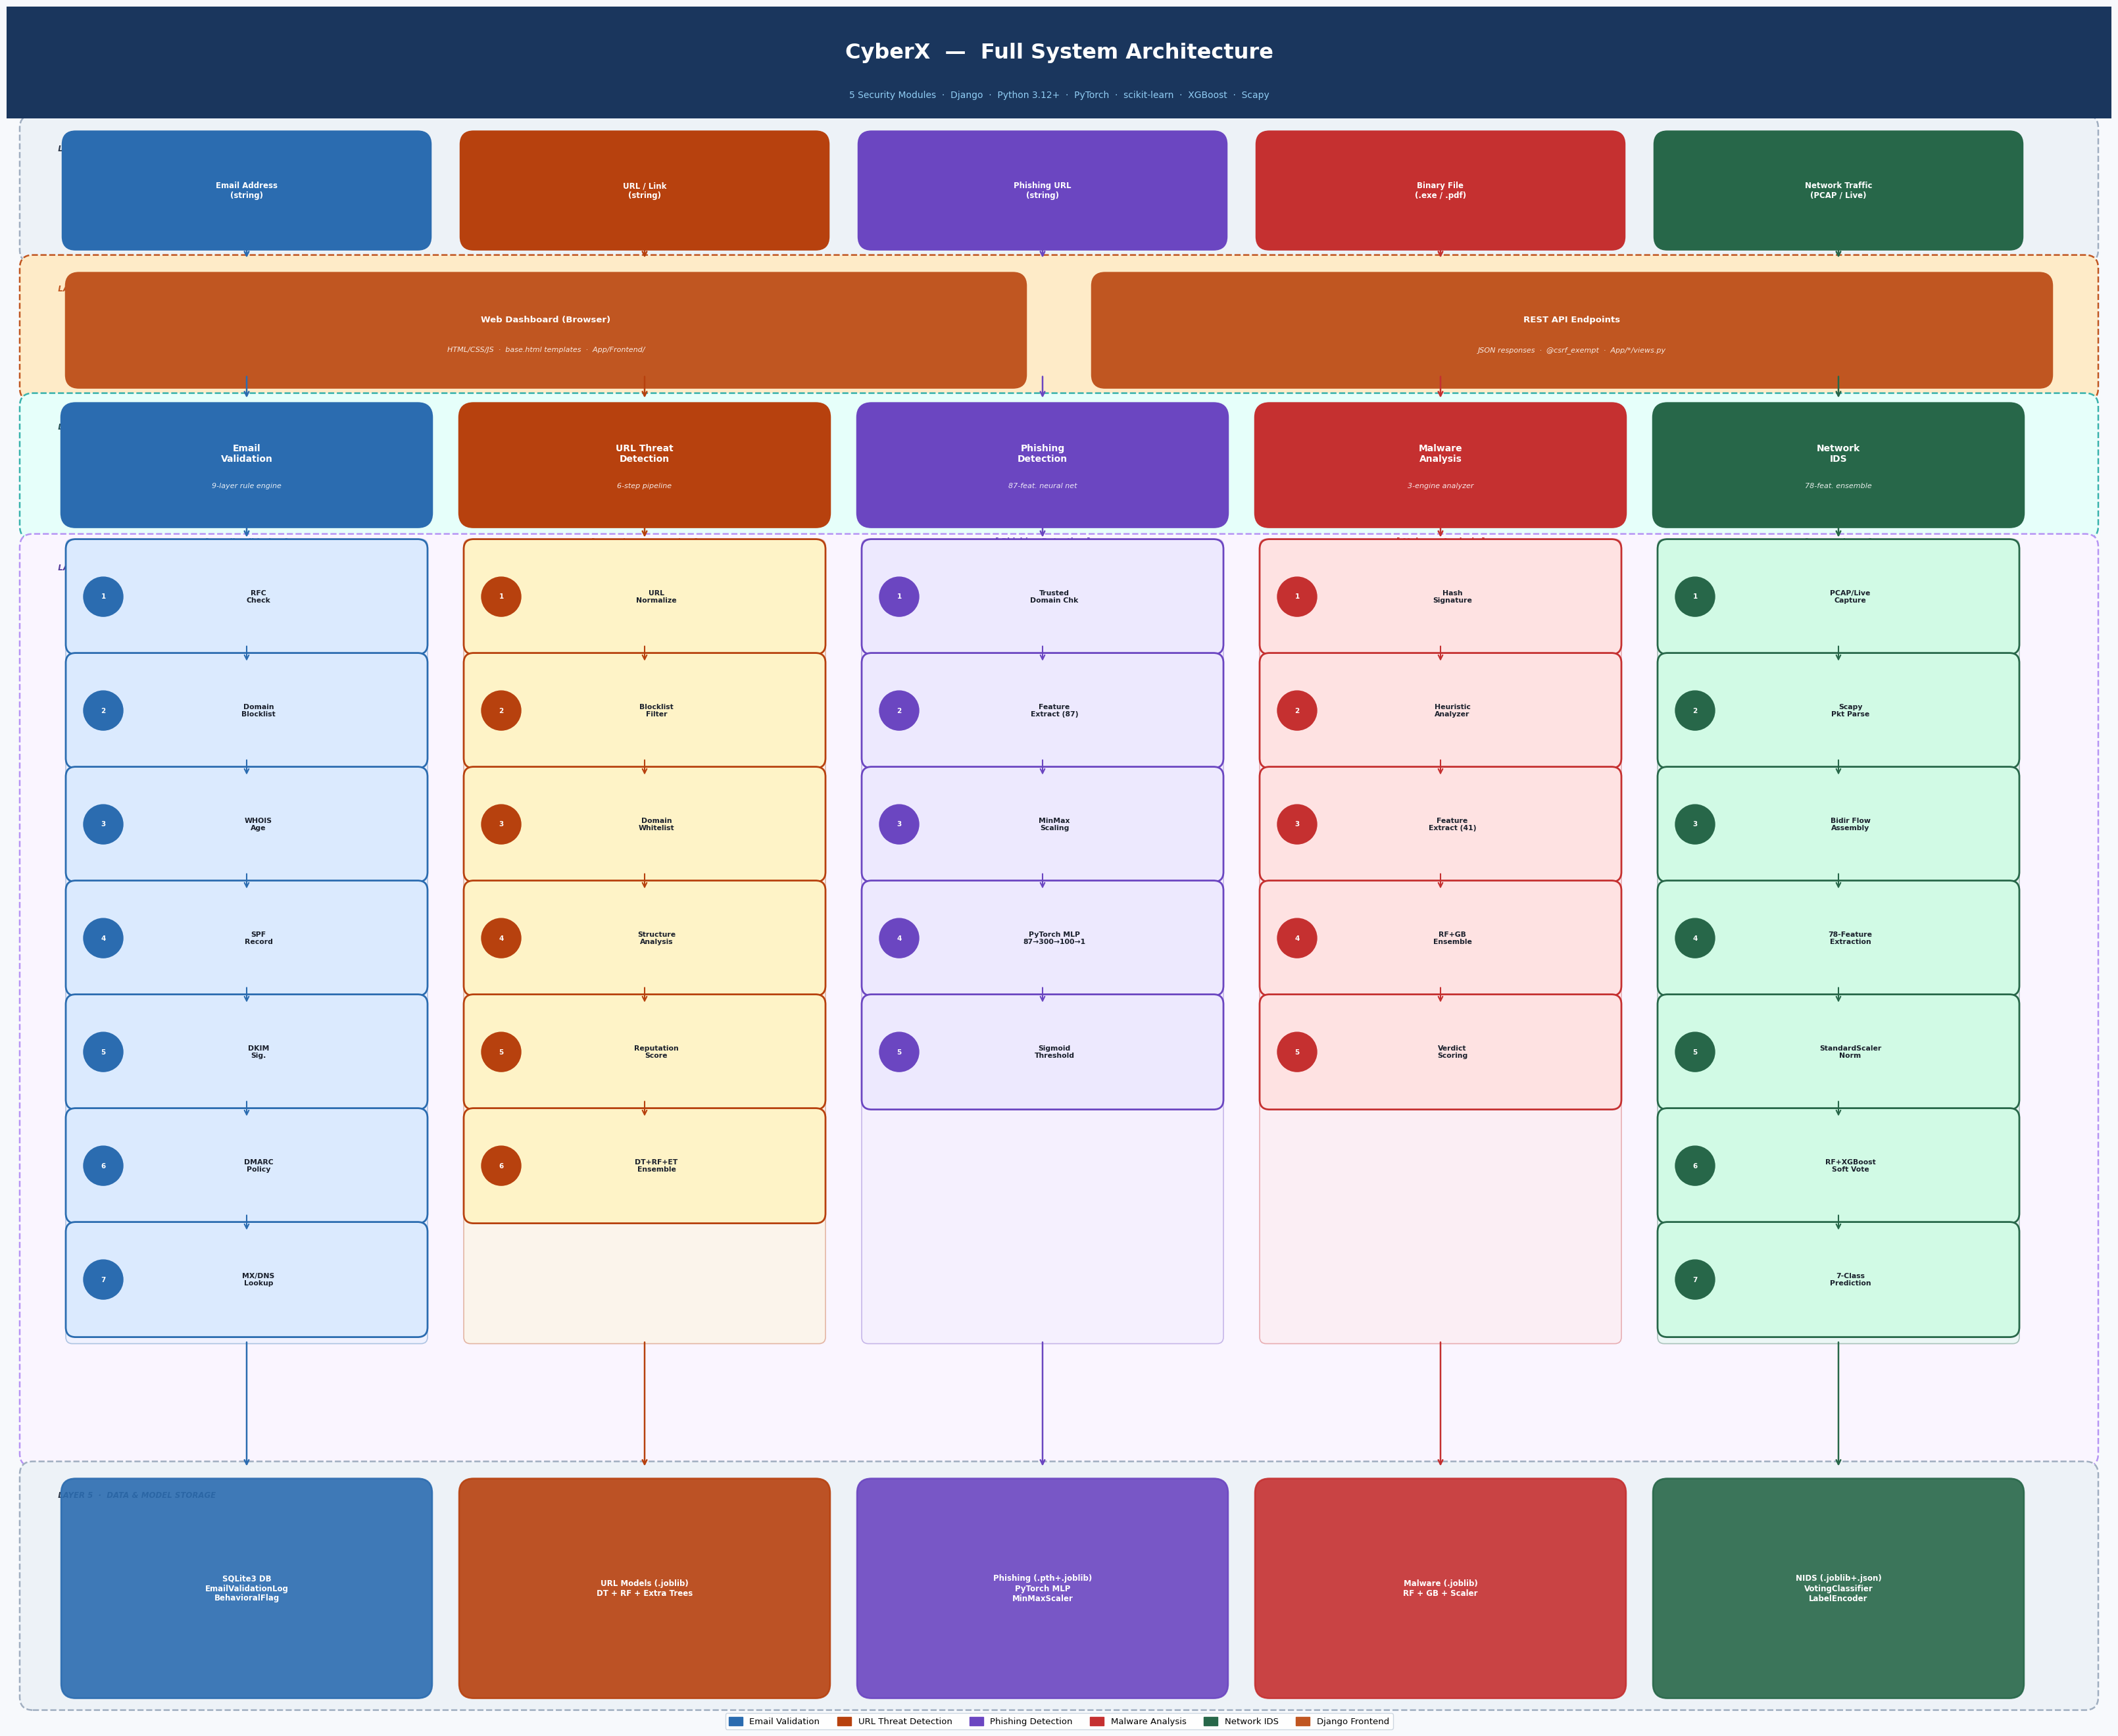

Architecture diagram saved → cyberx_architecture.png


In [8]:

# ── Cell 8: CyberX Architecture Diagram — Modern Column Layout ────────────────

# ─── Color System ────────────────────────────────────────────────────────────
C = {
    'bg':             '#F7F9FC',
    'title_bg':       '#1A365D',
    'title_text':     '#FFFFFF',
    'title_sub':      '#90CDF4',

    'email':          '#2B6CB0',
    'email_light':    '#DBEAFE',
    'url':            '#B7410E',
    'url_light':      '#FEF3C7',
    'phishing':       '#6B46C1',
    'phishing_light': '#EDE9FE',
    'malware':        '#C53030',
    'malware_light':  '#FEE2E2',
    'nids':           '#276749',
    'nids_light':     '#D1FAE5',

    'django':         '#C05621',
    'django_light':   '#FEEBC8',

    'storage_bg':     '#EDF2F7',
    'arrow':          '#4A5568',
    'text_dark':      '#1A202C',
}

MODULES      = ['email', 'url', 'phishing', 'malware', 'nids']
MODULE_LABEL = ['Email\nValidation', 'URL Threat\nDetection', 'Phishing\nDetection', 'Malware\nAnalysis', 'Network\nIDS']
MODULE_INPUT = ['Email Address\n(string)', 'URL / Link\n(string)', 'Phishing URL\n(string)',
                'Binary File\n(.exe / .pdf)', 'Network Traffic\n(PCAP / Live)']
MODULE_SUB   = ['9-layer rule engine', '6-step pipeline', '87-feat. neural net',
                '3-engine analyzer', '78-feat. ensemble']
MODULE_STORE = [
    'SQLite3 DB\nEmailValidationLog\nBehavioralFlag',
    'URL Models (.joblib)\nDT + RF + Extra Trees',
    'Phishing (.pth+.joblib)\nPyTorch MLP\nMinMaxScaler',
    'Malware (.joblib)\nRF + GB + Scaler',
    'NIDS (.joblib+.json)\nVotingClassifier\nLabelEncoder',
]

PIPELINES = {
    'email':    ['RFC\nCheck', 'Domain\nBlocklist', 'WHOIS\nAge',
                 'SPF\nRecord', 'DKIM\nSig.', 'DMARC\nPolicy', 'MX/DNS\nLookup'],
    'url':      ['URL\nNormalize', 'Blocklist\nFilter', 'Domain\nWhitelist',
                 'Structure\nAnalysis', 'Reputation\nScore', 'DT+RF+ET\nEnsemble', None],
    'phishing': ['Trusted\nDomain Chk', 'Feature\nExtract (87)', 'MinMax\nScaling',
                 'PyTorch MLP\n87→300→100→1', 'Sigmoid\nThreshold', None, None],
    'malware':  ['Hash\nSignature', 'Heuristic\nAnalyzer', 'Feature\nExtract (41)',
                 'RF+GB\nEnsemble', 'Verdict\nScoring', None, None],
    'nids':     ['PCAP/Live\nCapture', 'Scapy\nPkt Parse', 'Bidir Flow\nAssembly',
                 '78-Feature\nExtraction', 'StandardScaler\nNorm', 'RF+XGBoost\nSoft Vote', '7-Class\nPrediction'],
}

# ─── Canvas ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(32, 26), facecolor=C['bg'])
ax  = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 32)
ax.set_ylim(0, 26)
ax.axis('off')
ax.set_facecolor(C['bg'])

# Column geometry
COL_W, COL_GAP, MARGIN = 5.4, 0.8, 1.1
COL_X = [MARGIN + i * (COL_W + COL_GAP) for i in range(5)]
# Col centers: 3.8, 10.0, 16.2, 22.4, 28.6   (fits: 28.6+5.4+1.1=35.1 → using 32 so adjust)
# Recalculate to fill width 32 properly:
COL_W, COL_GAP, MARGIN = 5.2, 0.85, 1.05
COL_X = [MARGIN + i * (COL_W + COL_GAP) for i in range(5)]
# Verify: 5*5.2 + 4*0.85 + 2*1.05 = 26 + 3.4 + 2.1 = 31.5  (leaves 0.5 right margin ✓)

# ─── Helper Functions ─────────────────────────────────────────────────────────
def draw_card(ax, x, y, w, h, label, sub=None,
              fc='#2B6CB0', ec=None, tc='white',
              fs=9, sub_fs=7.5, pad=0.22, lw=1.8, alpha=1.0, zorder=3):
    if ec is None:
        ec = fc
    p = FancyBboxPatch((x, y), w, h, boxstyle=f"round,pad={pad}",
                       facecolor=fc, edgecolor=ec, linewidth=lw,
                       alpha=alpha, zorder=zorder)
    ax.add_patch(p)
    cy = y + h / 2 + (h * 0.12 if sub else 0)
    ax.text(x + w/2, cy, label, ha='center', va='center',
            color=tc, fontsize=fs, fontweight='bold', zorder=zorder+1)
    if sub:
        ax.text(x + w/2, y + h * 0.28, sub, ha='center', va='center',
                color=tc, fontsize=sub_fs, style='italic', zorder=zorder+1, alpha=0.88)

def draw_step(ax, x, y, w, h, num, label, fc, ec, fs=8):
    # Light background step with colored border + number badge
    p = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                       facecolor=fc, edgecolor=ec, linewidth=2.0, zorder=4)
    ax.add_patch(p)
    # Number badge
    badge = plt.Circle((x + 0.42, y + h/2), 0.3, color=ec, zorder=5)
    ax.add_patch(badge)
    ax.text(x + 0.42, y + h/2, str(num), ha='center', va='center',
            color='white', fontsize=7.5, fontweight='bold', zorder=6)
    # Label
    ax.text(x + w/2 + 0.18, y + h/2, label, ha='center', va='center',
            color=C['text_dark'], fontsize=fs, fontweight='bold', zorder=5)

def draw_arrow(ax, x1, y1, x2, y2, color='#718096', lw=1.8):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                mutation_scale=12), zorder=6)

def layer_strip(ax, x, y, w, h, label, fc, ec, lc, label_size=8.5):
    p = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.2",
                       facecolor=fc, edgecolor=ec, linewidth=1.8, linestyle='--', zorder=1)
    ax.add_patch(p)
    ax.text(x + 0.3, y + h - 0.25, label, ha='left', va='top',
            color=lc, fontsize=label_size, fontweight='bold', fontstyle='italic', zorder=2)

# ════════════════════════════════════════════════════════════════════════════════
#  TITLE BAND
# ════════════════════════════════════════════════════════════════════════════════
title_bg = FancyBboxPatch((0, 24.3), 32, 1.7, boxstyle="square,pad=0",
                           facecolor=C['title_bg'], edgecolor='none', zorder=2)
ax.add_patch(title_bg)
ax.text(16, 25.3, "CyberX  —  Full System Architecture",
        ha='center', va='center', fontsize=23, fontweight='bold',
        color=C['title_text'], zorder=3)
ax.text(16, 24.65, "5 Security Modules  ·  Django  ·  Python 3.12+  ·  PyTorch  ·  scikit-learn  ·  XGBoost  ·  Scapy",
        ha='center', va='center', fontsize=10, color=C['title_sub'], zorder=3)

# ════════════════════════════════════════════════════════════════════════════════
#  LAYER 1 — USER INPUTS
# ════════════════════════════════════════════════════════════════════════════════
layer_strip(ax, 0.4, 22.3, 31.2, 1.85, "  LAYER 1  ·  USER INPUTS",
            '#EDF2F7', '#A0AEC0', '#2D3748')
for i, (m, inp) in enumerate(zip(MODULES, MODULE_INPUT)):
    draw_card(ax, COL_X[i], 22.5, COL_W, 1.4,
              inp, fc=C[m], tc='white', fs=8.5, pad=0.2)

# Arrows → Django
for i, m in enumerate(MODULES):
    draw_arrow(ax, COL_X[i] + COL_W/2, 22.5, COL_X[i] + COL_W/2, 22.15, C[m])

# ════════════════════════════════════════════════════════════════════════════════
#  LAYER 2 — DJANGO FRONTEND
# ════════════════════════════════════════════════════════════════════════════════
layer_strip(ax, 0.4, 20.2, 31.2, 1.82, "  LAYER 2  ·  DJANGO FRONTEND  +  URL DISPATCHER",
            C['django_light'], C['django'], C['django'])
draw_card(ax, 1.1, 20.4, 14.2, 1.35,
          "Web Dashboard (Browser)",
          "HTML/CSS/JS  ·  base.html templates  ·  App/Frontend/",
          fc=C['django'], tc='white', fs=9.5, sub_fs=8, pad=0.2)
draw_card(ax, 16.7, 20.4, 14.2, 1.35,
          "REST API Endpoints",
          "JSON responses  ·  @csrf_exempt  ·  App/*/views.py",
          fc=C['django'], tc='white', fs=9.5, sub_fs=8, pad=0.2)

# Arrows → Modules
for i, m in enumerate(MODULES):
    draw_arrow(ax, COL_X[i] + COL_W/2, 20.4, COL_X[i] + COL_W/2, 20.02, C[m])

# ════════════════════════════════════════════════════════════════════════════════
#  LAYER 3 — MODULE APPS
# ════════════════════════════════════════════════════════════════════════════════
layer_strip(ax, 0.4, 18.1, 31.2, 1.82, "  LAYER 3  ·  DJANGO MODULE APPS  (App/)",
            '#E6FFFA', '#38B2AC', '#234E52')
for i, (m, name, sub) in enumerate(zip(MODULES, MODULE_LABEL, MODULE_SUB)):
    draw_card(ax, COL_X[i], 18.3, COL_W, 1.45,
              name, sub, fc=C[m], tc='white', fs=10, sub_fs=8, pad=0.22)

# Arrows → Pipeline
for i, m in enumerate(MODULES):
    draw_arrow(ax, COL_X[i] + COL_W/2, 18.3, COL_X[i] + COL_W/2, 17.9, C[m])

# ════════════════════════════════════════════════════════════════════════════════
#  LAYER 4 — DETECTION PIPELINES  (column per module)
# ════════════════════════════════════════════════════════════════════════════════
layer_strip(ax, 0.4, 4.0, 31.2, 13.78, "  LAYER 4  ·  DETECTION & ML INFERENCE PIPELINES",
            '#FAF5FF', '#B794F4', '#553C9A')

STEP_H   = 1.45
STEP_GAP = 0.28
PIPE_TOP = 17.75   # y-start of first step bottom-edge reference

for i, m in enumerate(MODULES):
    cx     = COL_X[i]
    steps  = PIPELINES[m]
    fc_lt  = C[m + '_light']
    fc_dk  = C[m]

    # Module pipeline header
    ax.text(cx + COL_W/2, PIPE_TOP + 0.05,
            f"[ {MODULE_LABEL[i].replace(chr(10),' ')} ]",
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color=fc_dk, zorder=4)

    # Draw column background tint
    real_steps = [s for s in steps if s is not None]
    col_h = len(steps) * (STEP_H + STEP_GAP) - STEP_GAP + 0.1
    bg = FancyBboxPatch((cx - 0.05, PIPE_TOP - col_h - 0.05), COL_W + 0.1, col_h + 0.1,
                        boxstyle="round,pad=0.1", facecolor=fc_lt, edgecolor=fc_dk,
                        linewidth=1.2, alpha=0.35, zorder=2)
    ax.add_patch(bg)

    y_cur = PIPE_TOP
    num   = 1
    for step in steps:
        y_top = y_cur - STEP_H
        if step is not None:
            draw_step(ax, cx, y_top, COL_W, STEP_H, num, step, fc_lt, fc_dk, fs=7.8)
            num += 1
            # Down-arrow to next non-None step
            next_step = next((s for s in steps[steps.index(step)+1:] if s is not None), None)
            if next_step is not None:
                draw_arrow(ax, cx + COL_W/2, y_top,
                           cx + COL_W/2, y_top - STEP_GAP, fc_dk, lw=1.5)
        y_cur -= (STEP_H + STEP_GAP)

# Arrows → Storage
for i, m in enumerate(MODULES):
    bottom_pipe = PIPE_TOP - len(PIPELINES[m]) * (STEP_H + STEP_GAP) + STEP_GAP - 0.2
    draw_arrow(ax, COL_X[i] + COL_W/2, max(bottom_pipe, 4.15),
               COL_X[i] + COL_W/2, 3.78, C[m])

# ════════════════════════════════════════════════════════════════════════════════
#  LAYER 5 — DATA & MODEL STORAGE
# ════════════════════════════════════════════════════════════════════════════════
layer_strip(ax, 0.4, 0.3, 31.2, 3.38, "  LAYER 5  ·  DATA & MODEL STORAGE",
            C['storage_bg'], '#A0AEC0', '#2D3748')
for i, (m, stor) in enumerate(zip(MODULES, MODULE_STORE)):
    draw_card(ax, COL_X[i], 0.5, COL_W, 2.9,
              stor, fc=C[m], tc='white', fs=8.5, pad=0.22, alpha=0.9)

# ════════════════════════════════════════════════════════════════════════════════
#  LEGEND
# ════════════════════════════════════════════════════════════════════════════════
legend_patches = [
    mpatches.Patch(color=C['email'],    label='Email Validation'),
    mpatches.Patch(color=C['url'],      label='URL Threat Detection'),
    mpatches.Patch(color=C['phishing'], label='Phishing Detection'),
    mpatches.Patch(color=C['malware'],  label='Malware Analysis'),
    mpatches.Patch(color=C['nids'],     label='Network IDS'),
    mpatches.Patch(color=C['django'],   label='Django Frontend'),
]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.01),
          ncol=6, fontsize=9.5, framealpha=0.95, edgecolor='#CBD5E0',
          handlelength=1.6, handleheight=1.2)

plt.savefig("cyberx_architecture.png", dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("Architecture diagram saved → cyberx_architecture.png")


---
## 8. Module-by-Module Deep Architecture Diagrams

Detailed pipeline views for each of the five modules showing internal stages and data flow.

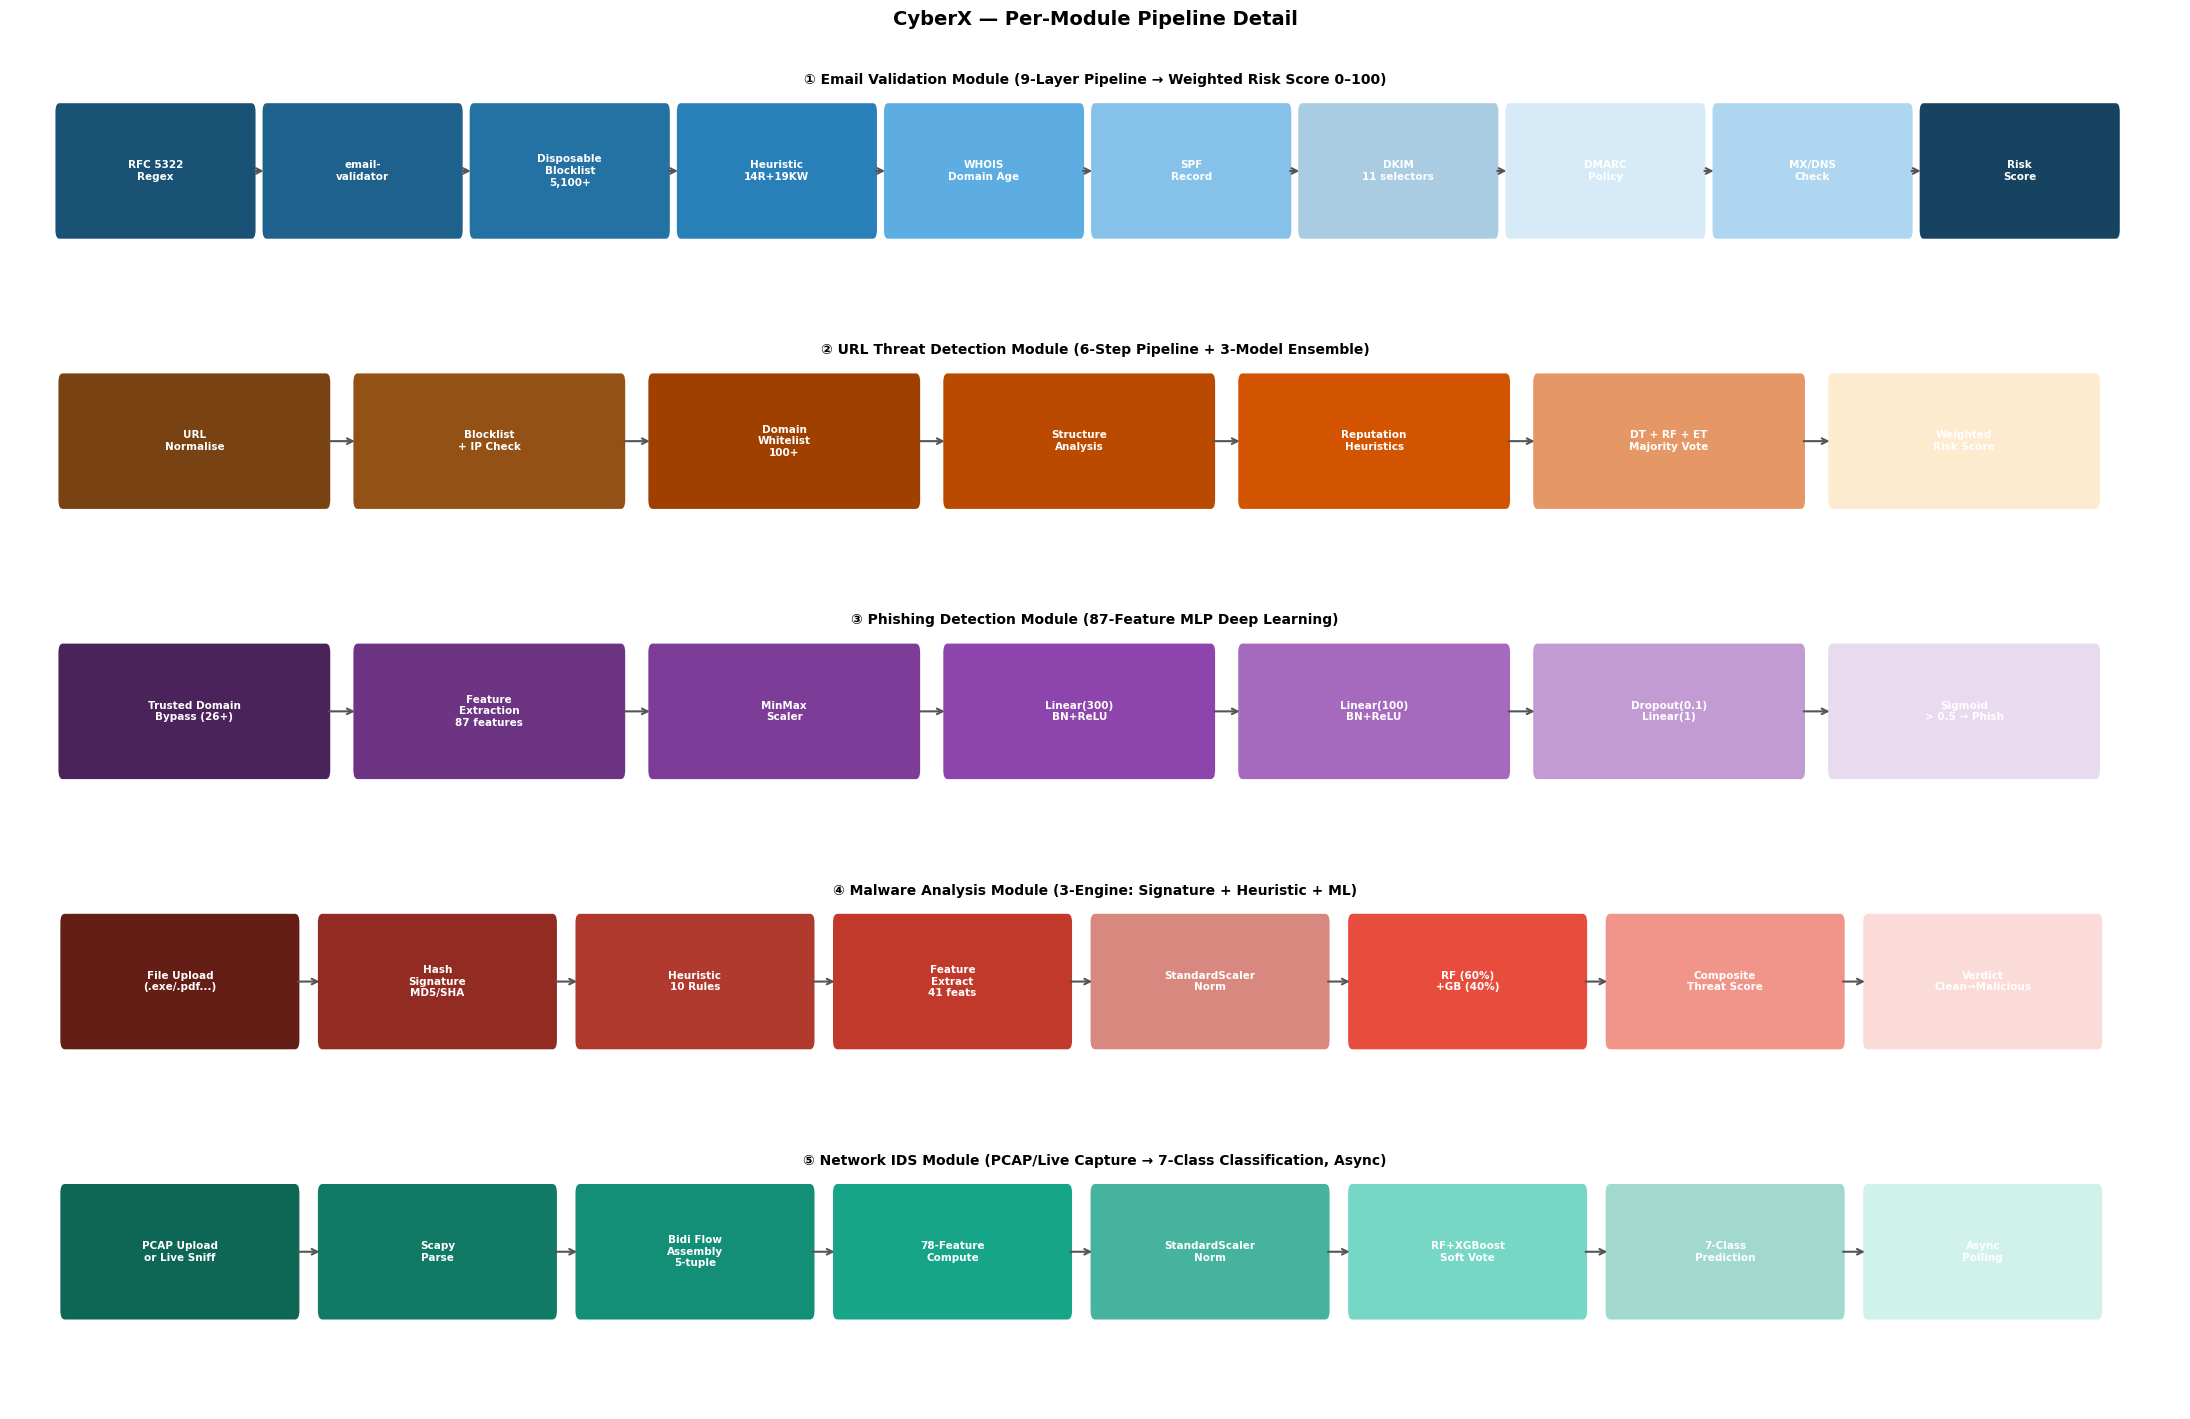

Per-module pipeline detail diagram saved.


In [9]:
# ── Cell 9: Per-Module Pipeline Detail Diagrams ────────────────────────────────

def pipeline_diagram(ax, title, stages, colors, start_x=0.5, y=0.5,
                     box_w=1.6, box_h=0.6, gap=0.25):
    """Draw a horizontal pipeline on an axes."""
    ax.set_xlim(0, start_x + len(stages)*(box_w+gap) + 0.5)
    ax.set_ylim(0, 1.2)
    ax.axis('off')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    for i, (label, col) in enumerate(zip(stages, colors)):
        x = start_x + i*(box_w+gap)
        box = FancyBboxPatch((x, y), box_w, box_h,
                             boxstyle="round,pad=0.05",
                             facecolor=col, edgecolor='white', linewidth=1.5)
        ax.add_patch(box)
        ax.text(x+box_w/2, y+box_h/2, label, ha='center', va='center',
                color='white', fontsize=7.5, fontweight='bold', wrap=True,
                multialignment='center')
        if i < len(stages)-1:
            ax.annotate('', xy=(x+box_w+gap, y+box_h/2),
                        xytext=(x+box_w, y+box_h/2),
                        arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))

fig, axes = plt.subplots(5, 1, figsize=(22, 14))
fig.suptitle("CyberX — Per-Module Pipeline Detail", fontsize=14, fontweight='bold', y=1.01)

# 1. Email Validation
pipeline_diagram(axes[0],
    "① Email Validation Module (9-Layer Pipeline → Weighted Risk Score 0–100)",
    ["RFC 5322\nRegex","email-\nvalidator","Disposable\nBlocklist\n5,100+",
     "Heuristic\n14R+19KW","WHOIS\nDomain Age","SPF\nRecord",
     "DKIM\n11 selectors","DMARC\nPolicy","MX/DNS\nCheck","Risk\nScore"],
    ['#1a5276','#1f618d','#2471a3','#2980b9','#5dade2','#85c1e9',
     '#a9cce3','#d6eaf8','#aed6f1','#154360'],
    box_w=1.95, gap=0.15)

# 2. URL Threat Detection
pipeline_diagram(axes[1],
    "② URL Threat Detection Module (6-Step Pipeline + 3-Model Ensemble)",
    ["URL\nNormalise","Blocklist\n+ IP Check","Domain\nWhitelist\n100+",
     "Structure\nAnalysis","Reputation\nHeuristics",
     "DT + RF + ET\nMajority Vote","Weighted\nRisk Score"],
    ['#784212','#935116','#a04000','#ba4a00','#d35400','#e59866','#fdebd0'],
    box_w=2.5, gap=0.3)

# 3. Phishing Detection
pipeline_diagram(axes[2],
    "③ Phishing Detection Module (87-Feature MLP Deep Learning)",
    ["Trusted Domain\nBypass (26+)","Feature\nExtraction\n87 features",
     "MinMax\nScaler",
     "Linear(300)\nBN+ReLU","Linear(100)\nBN+ReLU",
     "Dropout(0.1)\nLinear(1)","Sigmoid\n> 0.5 → Phish"],
    ['#4a235a','#6c3483','#7d3c98','#8e44ad','#a569bd','#c39bd3','#e8daef'],
    box_w=2.5, gap=0.3)

# 4. Malware Analysis
pipeline_diagram(axes[3],
    "④ Malware Analysis Module (3-Engine: Signature + Heuristic + ML)",
    ["File Upload\n(.exe/.pdf...)","Hash\nSignature\nMD5/SHA",
     "Heuristic\n10 Rules","Feature\nExtract\n41 feats",
     "StandardScaler\nNorm",
     "RF (60%)\n+GB (40%)","Composite\nThreat Score","Verdict\nClean→Malicious"],
    ['#641e16','#922b21','#b03a2e','#c0392b','#d98880','#e74c3c','#f1948a','#fadbd8'],
    box_w=2.1, gap=0.25)

# 5. Network IDS
pipeline_diagram(axes[4],
    "⑤ Network IDS Module (PCAP/Live Capture → 7-Class Classification, Async)",
    ["PCAP Upload\nor Live Sniff","Scapy\nParse",
     "Bidi Flow\nAssembly\n5-tuple","78-Feature\nCompute",
     "StandardScaler\nNorm",
     "RF+XGBoost\nSoft Vote",
     "7-Class\nPrediction","Async\nPolling"],
    ['#0e6655','#117a65','#148f77','#17a589','#45b39d','#76d7c4','#a2d9ce','#d1f2eb'],
    box_w=2.1, gap=0.25)

plt.tight_layout()
plt.savefig("cyberx_pipeline_details.png", dpi=150, bbox_inches='tight')
plt.show()
print("Per-module pipeline detail diagram saved.")

In [10]:
# ── Cell 10: Final Summary Statistics Table ─────────────────────────────────
print("=" * 70)
print("  CyberX Platform — Output Files Generated")
print("=" * 70)

outputs = [
    ("email_validation_matrix.png",   "Email Validation pipeline coverage + risk weights"),
    ("url_threat_matrix.png",         "URL Threat Detection per-model metrics + confusion matrix"),
    ("phishing_matrix.png",           "Phishing MLP metrics + confusion matrix + architecture"),
    ("malware_matrix.png",            "Malware ensemble accuracy + feature importance"),
    ("nids_matrix.png",               "NIDS per-class metrics + normalised confusion matrix"),
    ("overall_performance_table.png", "Consolidated 5-module performance summary table"),
    ("overall_radar_chart.png",       "Multi-dimension radar chart comparison"),
    ("cyberx_architecture.png",       "Full layered system architecture diagram"),
    ("cyberx_pipeline_details.png",   "Per-module pipeline detail diagrams"),
]

for fname, desc in outputs:
    path = Path(fname)
    status = "✓ SAVED" if path.exists() else "✗ MISSING"
    print(f"  {status}  {fname:<40}  {desc}")

print()
print("Performance Summary:")
print("-" * 70)
perf_rows = [
    ("Email Validation",  "Rule-based",   "N/A",     "N/A",     "N/A",    "N/A"),
    ("URL Threat",        "DT/RF/ET ens.","≥95.0%", "~96.9%",  "~96.8%", "~96.8%"),
    ("Phishing",          "PyTorch MLP",  "~95.0%",  "~95.2%",  "~95.2%", "~95.2%"),
    ("Malware",           "RF+GB ens.",   "100%*",   "100%*",   "100%*",  "100%*"),
    ("Network IDS",       "RF+XGBoost",  "98-100%", "~99.9%",  "~99.9%", "~99.9%"),
]
print(f"  {'Module':<22} {'Model':<16} {'Accuracy':<12} {'Precision':<12} {'Recall':<10} {'F1':<8}")
print("-" * 70)
for row in perf_rows:
    print(f"  {row[0]:<22} {row[1]:<16} {row[2]:<12} {row[3]:<12} {row[4]:<10} {row[5]:<8}")
print()
print("  * Malware: synthetic benchmark — real-world evaluation on EMBER/MalwareBazaar recommended.")

  CyberX Platform — Output Files Generated
  ✓ SAVED  email_validation_matrix.png               Email Validation pipeline coverage + risk weights
  ✓ SAVED  url_threat_matrix.png                     URL Threat Detection per-model metrics + confusion matrix
  ✓ SAVED  phishing_matrix.png                       Phishing MLP metrics + confusion matrix + architecture
  ✓ SAVED  malware_matrix.png                        Malware ensemble accuracy + feature importance
  ✓ SAVED  nids_matrix.png                           NIDS per-class metrics + normalised confusion matrix
  ✓ SAVED  overall_performance_table.png             Consolidated 5-module performance summary table
  ✓ SAVED  overall_radar_chart.png                   Multi-dimension radar chart comparison
  ✓ SAVED  cyberx_architecture.png                   Full layered system architecture diagram
  ✓ SAVED  cyberx_pipeline_details.png               Per-module pipeline detail diagrams

Performance Summary:
-------------------------------